<a href="https://colab.research.google.com/github/Rodriguez-A-Daniel/TFG-Ingenieria-Datos/blob/main/TFG_DRA_Ingenieria_Dato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INGENIERÍA DEL DATO
## Impacto del Real Decreto 958/2020 en el Mercado de Apuestas Online en España: Análisis Causal de Series Temporales

**Autor:** Daniel Rodríguez Aller  
**Universidad:** Universidad Francisco de Vitoria (UFV)

---

## Índice
1. Introducción y descripción del conjunto de datos
2. Carga y exploración inicial
3. Limpieza y tratamiento de datos
4. Transformaciones y homogeneización
5. Análisis Exploratorio (EDA)
6. Test de Estacionariedad (ADF) y Análisis de Autocorrelación (ACF/PACF)
7. Dataset maestro final
8. Conclusiones

---
## 1. Introducción y descripción del conjunto de datos

### 1.1 Contexto y justificación metodológica

El presente notebook recoge el proceso completo de ingeniería del dato para el TFG *Impacto del Real Decreto 958/2020 en el Mercado de Apuestas Online en España*. El objetivo es construir un dataset maestro limpio, homogéneo y correctamente transformado que sirva de base para la estimación posterior de un modelo SARIMAX con variables de intervención.

La ingeniería del dato no es un paso preliminar menor — es la fase que determina la validez de todas las inferencias causales posteriores. Un dataset mal construido, con series no deflactadas, frecuencias heterogéneas o variables redundantes, produce coeficientes sesgados en el modelo SARIMAX que pueden llevar a conclusiones erróneas sobre el efecto del decreto. Por ello, cada decisión tomada en esta fase se justifica explícitamente desde un criterio metodológico.

### 1.2 Inventario de fuentes de datos

Se combinan **tres fuentes oficiales** distintas. La elección de estas fuentes responde a criterios de fiabilidad, cobertura temporal y relevancia para el análisis causal:

| Archivo | Fuente | Contenido | Frecuencia | Periodo |
|---|---|---|---|---|
| JUEGO_ONLINE_2025.T4_GGR_CANT_JUGADAS.csv | DGOJ | GGR y cantidades jugadas por tipo de juego | Mensual | 2013-2025 |
| JUEGO_ONLINE_2025.T4_DEPOSITOS_RETIRADAS.csv | DGOJ | Depósitos, retiradas y nº de depósitos | Mensual | 2013-2025 |
| JUEGO_ONLINE_2025.T4_NUMERO_JUGADORES.csv | DGOJ | Cuentas activas y cuentas nuevas | Mensual | 2013-2025 |
| JUEGO_ONLINE_2025.T4_GASTOS_PROMOCION.csv | DGOJ | Publicidad, bonos, afiliados, patrocinio | Mensual | 2013-2025 |
| DATOS DMEJU CPJ PUBLICO 2020-2024 (1).xlsx | DGOJ / Min. Consumo | Datos económicos por CCAA y operador | Anual | 2020-2024 |
| 76125 (1).csv | INE — IPC | Índice de Precios de Consumo general | Mensual | 2002-2026 |
| 65219.csv | INE — EPA | Tasa de paro total nacional | Trimestral | 2002-2025 |
| 30679.csv | INE — CNTR | PIB tasa de variación anual | Trimestral | 1995-2025 |

### 1.3 Justificación detallada de cada variable

La selección de variables no es arbitraria. Cada variable incluida en el dataset maestro tiene una función específica en el análisis causal:

**Variables dependientes (lo que queremos explicar):**
- **GGR_real:** el Gross Gaming Revenue deflactado es la variable dependiente principal. Mide el ingreso neto del sector — lo que los jugadores pierden y los operadores ganan — en términos reales, eliminando el efecto de la inflación. Es la medida más directa de la actividad económica del sector.
- **Cuentas nuevas:** mide la velocidad de captación de nuevos jugadores. El decreto restringió directamente el gasto en captación (bonos de bienvenida, publicidad), por lo que se espera que esta variable sea la más sensible a la intervención.
- **Cuentas activas:** mide la base de jugadores que mantiene el mercado. A diferencia de las cuentas nuevas, refleja la retención, no la captación.
- **Depositos_real:** los depósitos deflactados miden la intensidad de juego de los jugadores activos — cuánto dinero real mueven. Si el decreto reduce la frecuencia de juego, los depósitos deberían caer incluso manteniendo el número de cuentas activas.

**Variables de gasto promocional (mecanismo del decreto):**
- **Gastos_real, Publicidad, Bonos, Afiliados, Patrocinio:** el RD 958/2020 actúa directamente sobre estos componentes. La caída en estas variables tras noviembre de 2021 es el **mecanismo de transmisión** del decreto hacia el GGR. Su inclusión permite verificar si el decreto actuó a través del canal previsto.

**Variables de control macroeconómico (confundidores):**
- **Tasa_paro:** controla el efecto del ciclo laboral sobre la demanda de apuestas. El desempleo reduce la renta disponible y por tanto el gasto discrecional. Sin este control, una subida del paro que coincida temporalmente con el decreto contaminaría el coeficiente estimado, haciéndolo aparecer más negativo de lo que realmente es.
- **PIB_var_anual:** controla el ciclo económico general. El juego online es un bien con elasticidad renta positiva — crece en expansión y se contrae en recesión. El periodo post-decreto (2022-2023) coincidió con una desaceleración económica tras la recuperación post-COVID, lo que podría confundirse con el efecto del decreto si no se controla.
- **IPC:** se usa para deflactar las variables nominales, no directamente como regresor en el modelo.
- **covid:** variable dicotómica que controla el periodo pandémico (marzo 2020 — diciembre 2021). Sin este control, el shock de COVID contaminaría la estimación del decreto porque ambos eventos son temporalmente cercanos.

**Variables eliminadas y justificación:**
- **Datos del xlsx histórico (DATOS DMEJU CPJ PUBLICO):** este archivo contiene datos anuales por CCAA y operador, útiles para contexto descriptivo pero no integrables en una serie temporal mensual sin supuestos de distribución que introducirían ruido. Se descarta para el dataset maestro y se reserva para análisis descriptivo en la memoria final.
- **GGR por categoría (Casino, Poker, Otros):** se mantienen como variables auxiliares pero no entran en el modelo principal porque están altamente correlacionadas con el GGR total, generando multicolinealidad. El análisis por categoría se reserva para modelos secundarios.
- **Nº de depósitos (conteo):** se descarta porque captura información redundante con los depósitos en valor — ambas variables miden la misma dimensión del comportamiento del jugador pero la monetaria es más informativa para el análisis económico.

### 1.4 Variable de intervención

El **Real Decreto 958/2020** fue aprobado en noviembre de 2020 pero su plena efectividad, especialmente la prohibición de bonos de bienvenida y publicidad en horario de máxima audiencia, se produjo en **noviembre de 2021**. Esta es la fecha utilizada como punto de quiebre estructural, siguiendo la literatura sobre análisis de intervención en series temporales (Box & Tiao, 1975). Se modela como una función escalón — efecto abrupto y permanente — ya que la restricción regulatoria no tiene un periodo de transición gradual.

---
## 2. Carga y exploración inicial

La exploración inicial sirve para verificar que los archivos se han cargado correctamente, entender la estructura de cada dataset (dimensiones, tipos de dato, periodo cubierto) y detectar posibles problemas de calidad antes de proceder con la limpieza. Es el equivalente a una auditoría de datos previa al preprocesamiento.

In [1]:
# CELDA 1 — Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print('Librerías cargadas correctamente')
import statsmodels
print(f'  pandas {pd.__version__} | numpy {np.__version__} | statsmodels {statsmodels.__version__}')

Librerías cargadas correctamente
  pandas 2.2.2 | numpy 2.0.2 | statsmodels 0.14.6


In [2]:
# CELDA 2 — Carga de los datasets
# RUTA = '' si subes los archivos directamente al panel de Colab
# RUTA = '/content/drive/MyDrive/TFG/' si usas Google Drive
RUTA = ''

df_ggr     = pd.read_csv(RUTA + 'JUEGO_ONLINE_2025.T4_GGR_CANT_JUGADAS.csv',    sep=';', encoding='utf-8')
df_dep     = pd.read_csv(RUTA + 'JUEGO_ONLINE_2025.T4_DEPOSITOS_RETIRADAS.csv', sep=';', encoding='utf-8')
df_jug     = pd.read_csv(RUTA + 'JUEGO_ONLINE_2025.T4_NUMERO_JUGADORES.csv',    sep=';', encoding='utf-8')
df_gas     = pd.read_csv(RUTA + 'JUEGO_ONLINE_2025.T4_GASTOS_PROMOCION.csv',    sep=';', encoding='utf-8')
df_hist    = pd.read_excel(RUTA + 'DATOS DMEJU CPJ PUBLICO 2020-2024 (1).xlsx', sheet_name='DATOS ECONOMICOS')
df_ipc_raw = pd.read_csv(RUTA + '76125 (1).csv',  sep=';', encoding='cp1252', decimal=',')
df_paro_raw= pd.read_csv(RUTA + '65219.csv',       sep=';', encoding='cp1252', decimal=',')
df_pib_raw = pd.read_csv(RUTA + '30679.csv',       sep=';', encoding='cp1252', decimal=',')

print('Todos los archivos cargados correctamente')
print(f'  GGR:       {df_ggr.shape[0]:,} filas x {df_ggr.shape[1]} columnas')
print(f'  Depositos: {df_dep.shape[0]:,} filas x {df_dep.shape[1]} columnas')
print(f'  Jugadores: {df_jug.shape[0]:,} filas x {df_jug.shape[1]} columnas')
print(f'  Gastos:    {df_gas.shape[0]:,} filas x {df_gas.shape[1]} columnas')
print(f'  IPC:       {df_ipc_raw.shape[0]:,} filas x {df_ipc_raw.shape[1]} columnas')
print(f'  Paro EPA:  {df_paro_raw.shape[0]:,} filas x {df_paro_raw.shape[1]} columnas')
print(f'  PIB CNTR:  {df_pib_raw.shape[0]:,} filas x {df_pib_raw.shape[1]} columnas')

Todos los archivos cargados correctamente
  GGR:       2,652 filas x 6 columnas
  Depositos: 156 filas x 6 columnas
  Jugadores: 156 filas x 5 columnas
  Gastos:    156 filas x 8 columnas
  IPC:       16,296 filas x 4 columnas
  Paro EPA:  3,744 filas x 4 columnas
  PIB CNTR:  17,360 filas x 6 columnas


In [3]:
# CELDA 3 — Exploración inicial: estructura y tipos de dato
datasets = {
    'GGR y Cantidades Jugadas': df_ggr,
    'Depositos y Retiradas':    df_dep,
    'Numero de Jugadores':      df_jug,
    'Gastos de Promocion':      df_gas
}

for nombre, df in datasets.items():
    print(f'\n=== {nombre} ===')
    print(f'  Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
    print(f'  Periodo: {df["Año"].min()} - {df["Año"].max()}')
    print(f'  Tipos:')
    print(df.dtypes.to_string())
    display(df.head(3))


=== GGR y Cantidades Jugadas ===
  Dimensiones: 2652 filas x 6 columnas
  Periodo: 2013 - 2025
  Tipos:
Año                    int64
Trimestre             object
Mes                   object
Juego                 object
Cantidades jugadas     int64
GGR                    int64


,Año,Trimestre,Mes,Juego,Cantidades jugadas,GGR
0,2013,2013.T1,Enero,Ap. Cruzadas,0,0
1,2013,2013.T1,Enero,Ap. Dep. de Contrap. Convencionales,162047262,9846318
2,2013,2013.T1,Enero,Ap. Dep. de Contrap. en Directo,0,0



=== Depositos y Retiradas ===
  Dimensiones: 156 filas x 6 columnas
  Periodo: 2013 - 2025
  Tipos:
Año                 int64
Trimestre          object
Mes                object
Depósitos           int64
Retiradas           int64
Nº de depósitos     int64


,Año,Trimestre,Mes,Depósitos,Retiradas,Nº de depósitos
0,2013,2013.T1,Enero,39803786,20772330,1464463
1,2013,2013.T1,Febrero,37468821,19126090,1354706
2,2013,2013.T1,Marzo,41835683,22526521,1417211



=== Numero de Jugadores ===
  Dimensiones: 156 filas x 5 columnas
  Periodo: 2013 - 2025
  Tipos:
Año                 int64
Trimestre          object
Mes                object
Cuentas activas     int64
Cuentas nuevas      int64


,Año,Trimestre,Mes,Cuentas activas,Cuentas nuevas
0,2013,2013.T1,Enero,289770,120555
1,2013,2013.T1,Febrero,287528,125069
2,2013,2013.T1,Marzo,305069,145874



=== Gastos de Promocion ===
  Dimensiones: 156 filas x 8 columnas
  Periodo: 2013 - 2025
  Tipos:
Año              int64
Trimestre       object
Mes             object
Publicidad       int64
Bonos            int64
Afiliados        int64
Patrocinio       int64
Total Gastos     int64


,Año,Trimestre,Mes,Publicidad,Bonos,Afiliados,Patrocinio,Total Gastos
0,2013,2013.T1,Enero,6056129,2443546,1102163,266825,9868663
1,2013,2013.T1,Febrero,5793865,3013126,1099009,219788,10125788
2,2013,2013.T1,Marzo,6747101,3006975,909130,235332,10898538


In [4]:
# CELDA 4 — Exploración datasets INE

# IPC
ipc_gen = df_ipc_raw[
    (df_ipc_raw['Grupos ECOICOP ver.2'] == 'Índice general') &
    (df_ipc_raw['Tipo de dato'] == 'Índice')
].copy()
print('=== IPC (INE) ===')
print(f'  Periodo: {ipc_gen["Periodo"].iloc[-1]} a {ipc_gen["Periodo"].iloc[1]}')
print(f'  Obs: {len(ipc_gen)} | Nulos: {ipc_gen["Total"].isnull().sum()}')
display(ipc_gen.head(3))

# Tasa de paro — conversión a float necesaria (decimales con coma)
paro = df_paro_raw[
    (df_paro_raw['Edad'] == 'Total') &
    (df_paro_raw['Sexo'] == 'Ambos sexos')
].copy()
paro['Total'] = paro['Total'].astype(str).str.replace(',', '.').astype(float)
print()
print('=== Tasa de paro EPA (INE) ===')
print(f'  Periodo: {paro["Periodo"].iloc[-1]} a {paro["Periodo"].iloc[0]}')
print(f'  Obs: {len(paro)} | Nulos: {paro["Total"].isnull().sum()}')
display(paro.head(3))

# PIB
pib = df_pib_raw[
    (df_pib_raw['Tipo de dato'] == 'Datos no ajustados de estacionalidad y calendario') &
    (df_pib_raw['Niveles y tasas'] == 'Variación anual') &
    (df_pib_raw['Agregados macroeconómicos: Nivel 1'] == 'Producto interior bruto a precios de mercado') &
    (df_pib_raw['Agregados macroeconómicos: Nivel 2'].isna())
].copy()
print()
print('=== PIB Variación anual CNTR (INE) ===')
print(f'  Periodo: {pib["Periodo"].iloc[-1]} a {pib["Periodo"].iloc[0]}')
print(f'  Obs: {len(pib)} | Nulos: {pib["Total"].isnull().sum()}')
display(pib.head(3))

=== IPC (INE) ===
  Periodo: 2002M01 a 2026M02
  Obs: 291 | Nulos: 1


,Grupos ECOICOP ver.2,Tipo de dato,Periodo,Total
0,Índice general,Índice,2026M03,NaN
1,Índice general,Índice,2026M02,101.261
2,Índice general,Índice,2026M01,100.836



=== Tasa de paro EPA (INE) ===
  Periodo: 2002T1 a 2025T4
  Obs: 96 | Nulos: 0


,Edad,Sexo,Periodo,Total
0,Total,Ambos sexos,2025T4,9.93
1,Total,Ambos sexos,2025T3,10.45
2,Total,Ambos sexos,2025T2,10.29



=== PIB Variación anual CNTR (INE) ===
  Periodo: 1995T1 a 2025T4
  Obs: 124 | Nulos: 10


,Tipo de dato,Agregados macroeconómicos: Nivel 1,Agregados macroeconómicos: Nivel 2,Niveles y tasas,Periodo,Total
248,Datos no ajustados de estacionalidad y calendario,Producto interior bruto a precios de mercado,NaN,Variación anual,2025T4,NaN
249,Datos no ajustados de estacionalidad y calendario,Producto interior bruto a precios de mercado,NaN,Variación anual,2025T3,NaN
250,Datos no ajustados de estacionalidad y calendario,Producto interior bruto a precios de mercado,NaN,Variación anual,2025T2,NaN


---
## 3. Limpieza y tratamiento de datos

### Criterios de limpieza y justificación científica

**Valores nulos — interpolación lineal:**
En series temporales económicas, la técnica de imputación debe ser coherente con la estructura temporal de los datos. La interpolación lineal estima el valor ausente como una función lineal de los valores adyacentes anteriores y posteriores, lo que respeta la continuidad de la serie. Esto es metodológicamente superior a la imputación por media global o por moda porque:
- La media global ignora la tendencia: en una serie creciente, imputar la media subestimaría los valores recientes.
- La moda es adecuada para variables categóricas, no para variables continuas con tendencia temporal.
- La interpolación lineal es el método estándar recomendado en econometría de series temporales cuando la proporción de nulos es baja (< 5%) y los datos ausentes son aleatorios, no sistemáticos.

Como respaldo para los extremos de la serie (donde no hay valores adyacentes en una dirección), se usa `bfill` (relleno hacia atrás) y `ffill` (relleno hacia adelante).

**Outliers — preservación justificada:**
Los valores extremos en series temporales económicas raramente son errores de medición — suelen ser la huella de eventos reales extraordinarios. En este caso, los outliers detectados corresponden al periodo COVID-19 (caída del GGR en marzo-abril 2020 por el cierre del deporte profesional) y a la recuperación post-pandemia (rebote en 2021). Eliminarlos distorsionaría la dinámica real de la serie y sesgaría el modelo de intervención, que necesita ver exactamente qué ocurrió antes y después del decreto, incluyendo el contexto pandémico.

In [5]:
# CELDA 5 — Diagnóstico completo de calidad
print('DIAGNÓSTICO DE VALORES NULOS — DATASETS DGOJ')
print('='*60)
for nombre, df in datasets.items():
    nulos = df.isnull().sum()
    total = nulos.sum()
    pct = total / (df.shape[0]*df.shape[1]) * 100
    estado = 'Sin nulos' if total == 0 else f'{total} nulos ({pct:.2f}%)'
    print(f'  {nombre}: {estado}')

print()
print('DIAGNÓSTICO DE NULOS — DATASETS INE')
print('='*60)
print(f'  IPC:       {ipc_gen["Total"].isnull().sum()} nulos')
print(f'  Paro EPA:  {paro["Total"].isnull().sum()} nulos')
print(f'  PIB CNTR:  {pib["Total"].isnull().sum()} nulos (trimestres recientes no publicados)')

print()
print('DIAGNÓSTICO DE DUPLICADOS')
print('='*60)
for nombre, df in datasets.items():
    print(f'  {nombre}: {df.duplicated().sum()} duplicados')

DIAGNÓSTICO DE VALORES NULOS — DATASETS DGOJ
  GGR y Cantidades Jugadas: Sin nulos
  Depositos y Retiradas: Sin nulos
  Numero de Jugadores: Sin nulos
  Gastos de Promocion: Sin nulos

DIAGNÓSTICO DE NULOS — DATASETS INE
  IPC:       1 nulos
  Paro EPA:  0 nulos
  PIB CNTR:  10 nulos (trimestres recientes no publicados)

DIAGNÓSTICO DE DUPLICADOS
  GGR y Cantidades Jugadas: 0 duplicados
  Depositos y Retiradas: 0 duplicados
  Numero de Jugadores: 0 duplicados
  Gastos de Promocion: 0 duplicados


In [6]:
# CELDA 6 — Tratamiento de nulos con criterio explícito por variable

# IPC: el nulo es el dato adelantado de marzo 2026, no publicado por el INE.
# Criterio: eliminación, no interpolación, porque no es un dato ausente
# aleatorio sino un placeholder vacío de un periodo futuro.
print(f'IPC ANTES:   {len(ipc_gen)} filas | {ipc_gen["Total"].isnull().sum()} nulos')
ipc_gen = ipc_gen.dropna(subset=['Total']).copy()
print(f'IPC DESPUÉS: {len(ipc_gen)} filas | {ipc_gen["Total"].isnull().sum()} nulos')
print('  Criterio: dato adelantado no publicado — eliminación, no interpolación')
print()

# PIB: los nulos son trimestres con avance preliminar no disponible.
# Mismo criterio que el IPC — son periodos futuros, no datos ausentes.
print(f'PIB ANTES:   {len(pib)} filas | {pib["Total"].isnull().sum()} nulos')
pib = pib.dropna(subset=['Total']).copy()
print(f'PIB DESPUÉS: {len(pib)} filas | {pib["Total"].isnull().sum()} nulos')
print('  Criterio: trimestres con avance preliminar no publicado — eliminación')

IPC ANTES:   291 filas | 1 nulos
IPC DESPUÉS: 290 filas | 0 nulos
  Criterio: dato adelantado no publicado — eliminación, no interpolación

PIB ANTES:   124 filas | 10 nulos
PIB DESPUÉS: 114 filas | 0 nulos
  Criterio: trimestres con avance preliminar no publicado — eliminación


In [7]:
# CELDA 7 — Detección de outliers con método IQR
print('DETECCIÓN DE OUTLIERS (método IQR — umbral 1.5)')
print('='*60)
print('Criterio: outliers PRESERVADOS — corresponden a eventos reales')
print('(COVID-19 en 2020, recuperación post-pandemia 2021)')
print('Eliminarlos sesgaria el modelo de intervención.')
print()

def detectar_outliers(series, nombre):
    s = pd.to_numeric(series, errors='coerce').dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    out = s[(s < Q1-1.5*IQR) | (s > Q3+1.5*IQR)]
    print(f'  {nombre}: {len(out)} outliers ({len(out)/len(s)*100:.1f}%)')
    if len(out) > 0:
        print(f'    Rango normal: [{Q1-1.5*IQR:,.0f} — {Q3+1.5*IQR:,.0f}]')
    print()

ggr_mes = df_ggr.groupby(['Año','Mes'])['GGR'].sum().reset_index()
detectar_outliers(df_dep['Depósitos'],      'Depósitos')
detectar_outliers(df_jug['Cuentas nuevas'], 'Cuentas nuevas')
detectar_outliers(df_gas['Total Gastos'],   'Total Gastos')
detectar_outliers(ggr_mes['GGR'],           'GGR Total mensual')
detectar_outliers(paro['Total'],            'Tasa de paro')

DETECCIÓN DE OUTLIERS (método IQR — umbral 1.5)
Criterio: outliers PRESERVADOS — corresponden a eventos reales
(COVID-19 en 2020, recuperación post-pandemia 2021)
Eliminarlos sesgaria el modelo de intervención.

  Depósitos: 0 outliers (0.0%)

  Cuentas nuevas: 9 outliers (5.8%)
    Rango normal: [8,676 — 299,174]

  Total Gastos: 0 outliers (0.0%)

  GGR Total mensual: 1 outliers (0.6%)
    Rango normal: [-44,087,807 — 161,469,532]

  Tasa de paro: 0 outliers (0.0%)



---
## 4. Transformaciones y homogeneización

### Justificación del pipeline de transformaciones

Las transformaciones se aplican en un orden lógico que respeta las dependencias entre pasos:

**1. Creación de columna Fecha:** prerequisito para todas las operaciones temporales posteriores. Sin un índice temporal en formato datetime no es posible hacer merges por fecha, descomposición estacional ni test de series temporales.

**2. Agregación del GGR:** el dataset original tiene una fila por tipo de juego y mes (17 tipos × 156 meses = 2.652 filas). Para el análisis principal se necesita una fila por mes. La categorización en 4 grupos (Apuestas Deportivas, Casino, Póquer, Otros) permite análisis secundarios por segmento.

**3. Transformación del IPC y series trimestrales:** convierte los formatos de periodo del INE a datetime y expande la frecuencia trimestral a mensual. La expansión se hace **antes** del merge para garantizar que todas las series tienen exactamente el mismo índice temporal.

**4. Merge:** une todas las fuentes por la columna Fecha. Se usa `how='left'` con el dataset de depósitos como base porque tiene la cobertura temporal más completa.

**5. Deflactación:** se aplica **después** del merge para asegurar que el IPC ya está disponible en el dataset maestro. La deflactación transforma euros corrientes en euros reales (base 2021).

**6. Creación de variables de intervención:** se aplica al final porque requiere que la columna Fecha esté disponible en el dataset maestro.

In [8]:
# CELDA 8 — Crear columna Fecha en datasets DGOJ
meses_es = {
    'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,
    'Mayo':5,'Junio':6,'Julio':7,'Agosto':8,
    'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12
}

def crear_fecha(df):
    df = df.copy()
    df['Mes_num'] = df['Mes'].map(meses_es)
    df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes_num'].astype(str) + '-01')
    return df.sort_values('Fecha').reset_index(drop=True)

df_dep = crear_fecha(df_dep)
df_jug = crear_fecha(df_jug)
df_gas = crear_fecha(df_gas)
df_ggr = crear_fecha(df_ggr)

print('Columna Fecha creada en todos los datasets DGOJ')
print(f'  Rango: {df_dep["Fecha"].min().strftime("%b %Y")} a {df_dep["Fecha"].max().strftime("%b %Y")}')
print(f'  Total meses: {df_dep["Fecha"].nunique()}')
display(df_dep[['Fecha','Año','Mes','Depósitos']].head(3))

Columna Fecha creada en todos los datasets DGOJ
  Rango: Jan 2013 a Dec 2025
  Total meses: 156


,Fecha,Año,Mes,Depósitos
0,2013-01-01,2013,Enero,39803786
1,2013-02-01,2013,Febrero,37468821
2,2013-03-01,2013,Marzo,41835683


In [9]:
# CELDA 9 — Agregación del GGR y categorización
# Criterio de categorización: las Apuestas Deportivas son el segmento
# más expuesto a la publicidad restringida por el RD 958/2020 (patrocinio
# de equipos, publicidad en retransmisiones deportivas, bonos de apuesta).
# Casino y Póquer tienen una dinámica diferente y menos dependencia de la
# captación publicitaria masiva.

ap_dep = ['Ap. Dep. de Contrap. Convencionales','Ap. Dep. de Contrap. en Directo',
          'Ap. Cruzadas','Ap. Deportivas Mutuas','Otras Ap. de Contrapartida']
casino = ['Black Jack','Punto y Banca','Ruleta Convencional','Ruleta en Vivo']
poker  = ['Póquer Cash','Póquer Torneo']

df_ggr['Categoria'] = df_ggr['Juego'].apply(
    lambda x: 'Ap_Deportivas' if x in ap_dep
    else ('Casino' if x in casino
    else ('Poker' if x in poker else 'Otros'))
)

ggr_mensual = df_ggr.groupby('Fecha').agg(
    GGR_Total=('GGR','sum'),
    Cantidades_Total=('Cantidades jugadas','sum')
).reset_index()

ggr_cat = df_ggr.groupby(['Fecha','Categoria'])['GGR'].sum().unstack(fill_value=0).reset_index()
ggr_cat.columns = ['Fecha'] + ['GGR_' + c for c in ggr_cat.columns[1:]]

print('GGR agregado y categorizado')
print(f'  Meses: {len(ggr_mensual)} | Categorias: {[c for c in ggr_cat.columns if c!="Fecha"]}')
display(ggr_mensual.head(3))

GGR agregado y categorizado
  Meses: 156 | Categorias: ['GGR_Ap_Deportivas', 'GGR_Casino', 'GGR_Otros', 'GGR_Poker']


,Fecha,GGR_Total,Cantidades_Total
0,2013-01-01,20966725,490782627
1,2013-02-01,20277768,456031108
2,2013-03-01,20920774,498364413


In [10]:
# CELDA 10 — Transformación del IPC
ipc_clean = ipc_gen[['Periodo','Total']].copy()
ipc_clean.columns = ['Periodo_raw','IPC']
ipc_clean['Fecha'] = pd.to_datetime(ipc_clean['Periodo_raw'].str.replace('M','-') + '-01')
ipc_clean = ipc_clean[
    (ipc_clean['Fecha'] >= '2013-01-01') &
    (ipc_clean['Fecha'] <= '2025-12-31')
][['Fecha','IPC']].reset_index(drop=True)

print('IPC transformado')
print(f'  Periodo: {ipc_clean["Fecha"].min().strftime("%b %Y")} a {ipc_clean["Fecha"].max().strftime("%b %Y")}')
print(f'  Obs: {len(ipc_clean)} | Nulos: {ipc_clean["IPC"].isnull().sum()}')
display(ipc_clean.head(3))

IPC transformado
  Periodo: Jan 2013 a Dec 2025
  Obs: 156 | Nulos: 0


,Fecha,IPC
0,2025-12-01,101.289
1,2025-11-01,100.943
2,2025-10-01,100.748


In [11]:
# CELDA 11 — Expansión de la Tasa de Paro (trimestral → mensual)
# Justificación de la técnica: la expansión por repetición del valor
# trimestral en los 3 meses correspondientes es el estándar en
# econometría cuando se usan controles de baja frecuencia en modelos
# de alta frecuencia. Alternativas como la interpolación cúbica o
# el modelo de Chow-Lin son más sofisticadas pero requieren supuestos
# adicionales sobre la distribución intra-trimestral que no están
# justificados para la tasa de paro, que el INE publica expresamente
# como medida trimestral sin variación intra-trimestral.

def trimestre_a_fecha(t):
    año = int(t[:4])
    q   = int(t[5])
    mes = (q-1)*3 + 1
    return pd.Timestamp(año, mes, 1)

paro_clean = paro[['Periodo','Total']].copy()
paro_clean.columns = ['Trimestre','Tasa_paro']
paro_clean['Fecha_trim'] = paro_clean['Trimestre'].apply(trimestre_a_fecha)
paro_clean = paro_clean[
    (paro_clean['Fecha_trim'] >= '2013-01-01') &
    (paro_clean['Fecha_trim'] <= '2025-12-31')
].sort_values('Fecha_trim').reset_index(drop=True)

fechas_mensuales = pd.date_range('2013-01-01', '2025-12-01', freq='MS')
paro_mensual = pd.DataFrame({'Fecha': fechas_mensuales})
paro_mensual['Fecha_trim'] = paro_mensual['Fecha'].apply(
    lambda d: pd.Timestamp(d.year, ((d.month-1)//3)*3+1, 1)
)
paro_mensual = paro_mensual.merge(
    paro_clean[['Fecha_trim','Tasa_paro']], on='Fecha_trim', how='left'
)[['Fecha','Tasa_paro']]
paro_mensual['Tasa_paro'] = paro_mensual['Tasa_paro'].interpolate(method='linear')

print('Tasa de paro expandida a mensual')
print(f'  Obs: {len(paro_mensual)} | Nulos: {paro_mensual["Tasa_paro"].isnull().sum()}')
display(paro_mensual.head(6))

Tasa de paro expandida a mensual
  Obs: 156 | Nulos: 0


,Fecha,Tasa_paro
0,2013-01-01,26.94
1,2013-02-01,26.94
2,2013-03-01,26.94
3,2013-04-01,26.06
4,2013-05-01,26.06
5,2013-06-01,26.06


In [12]:
# CELDA 12 — Expansión del PIB (trimestral → mensual)
# Se usa la tasa de variación anual (no la trimestral) porque elimina
# la estacionalidad del propio PIB, evitando introducir un patrón
# estacional adicional que interferiría con el componente S del SARIMAX.
# La variación anual mide el crecimiento económico de fondo, que es
# el confundidor que queremos controlar.

pib_clean = pib[['Periodo','Total']].copy()
pib_clean.columns = ['Trimestre','PIB_var_anual']
pib_clean['Fecha_trim'] = pib_clean['Trimestre'].apply(trimestre_a_fecha)
pib_clean = pib_clean[
    (pib_clean['Fecha_trim'] >= '2013-01-01') &
    (pib_clean['Fecha_trim'] <= '2025-12-31')
].sort_values('Fecha_trim').reset_index(drop=True)

pib_mensual = pd.DataFrame({'Fecha': fechas_mensuales})
pib_mensual['Fecha_trim'] = pib_mensual['Fecha'].apply(
    lambda d: pd.Timestamp(d.year, ((d.month-1)//3)*3+1, 1)
)
pib_mensual = pib_mensual.merge(
    pib_clean[['Fecha_trim','PIB_var_anual']], on='Fecha_trim', how='left'
)[['Fecha','PIB_var_anual']]
pib_mensual['PIB_var_anual'] = pib_mensual['PIB_var_anual'].interpolate(method='linear')

print('PIB expandido a mensual')
print(f'  Obs: {len(pib_mensual)} | Nulos: {pib_mensual["PIB_var_anual"].isnull().sum()}')
display(pib_mensual.head(6))

PIB expandido a mensual
  Obs: 156 | Nulos: 0


,Fecha,PIB_var_anual
0,2013-01-01,-2.9697
1,2013-02-01,-2.9697
2,2013-03-01,-2.9697
3,2013-04-01,-1.2348
4,2013-05-01,-1.2348
5,2013-06-01,-1.2348


In [13]:
# CELDA 13 — Merge: dataset maestro
# Nota sobre variables excluidas del merge:
# - 'Nº de depósitos': excluido por redundancia con 'Depósitos' en valor.
#   Ambas miden la misma dimensión del comportamiento del jugador pero
#   la variable monetaria es más informativa para el análisis económico.
# - GGR por categoría: se incluyen como auxiliares pero no serán
#   regresores principales para evitar multicolinealidad con GGR_Total.
# - Datos del xlsx histórico (CCAA/operador): no integrables en serie
#   mensual sin supuestos de distribución que introducirían ruido.

cols_dep = ['Fecha','Año','Mes','Depósitos','Retiradas']
cols_jug = ['Fecha','Cuentas activas','Cuentas nuevas']
cols_gas = ['Fecha','Publicidad','Bonos','Afiliados','Patrocinio','Total Gastos']

df_master = (
    df_dep[cols_dep]
    .merge(df_jug[cols_jug],  on='Fecha', how='left')
    .merge(df_gas[cols_gas],  on='Fecha', how='left')
    .merge(ggr_mensual,       on='Fecha', how='left')
    .merge(ggr_cat,           on='Fecha', how='left')
    .merge(ipc_clean,         on='Fecha', how='left')
    .merge(paro_mensual,      on='Fecha', how='left')
    .merge(pib_mensual,       on='Fecha', how='left')
)

print('Dataset maestro construido')
print(f'  Dimensiones: {df_master.shape[0]} filas x {df_master.shape[1]} columnas')
print(f'  Periodo: {df_master["Fecha"].min().strftime("%B %Y")} a {df_master["Fecha"].max().strftime("%B %Y")}')
print(f'  Nulos post-merge: {df_master.isnull().sum().sum()}')

Dataset maestro construido
  Dimensiones: 156 filas x 21 columnas
  Periodo: January 2013 a December 2025
  Nulos post-merge: 0


In [14]:
# CELDA 14 — Interpolación post-merge y verificación
print('ANTES de la interpolación:')
nulos = df_master.isnull().sum()
print(nulos[nulos > 0].to_string() if nulos.sum() > 0 else '  Sin nulos')

cols_num = df_master.select_dtypes(include=[np.number]).columns.tolist()
df_master[cols_num] = df_master[cols_num].interpolate(method='linear')
df_master[cols_num] = df_master[cols_num].fillna(method='bfill').fillna(method='ffill')

print()
print('DESPUÉS de la interpolación:')
nulos2 = df_master.isnull().sum()
print(nulos2[nulos2 > 0].to_string() if nulos2.sum() > 0 else '  Sin nulos — dataset completo')

ANTES de la interpolación:
  Sin nulos

DESPUÉS de la interpolación:
  Sin nulos — dataset completo


In [15]:
# CELDA 15 — Deflactación y variables de intervención
# Deflactación: GGR_real = GGR_nominal / (IPC/100)
# La inflación acumulada entre 2013 y 2025 supera el 35%, lo que
# significa que sin deflactar estaríamos comparando euros de 2013
# con euros de 2025 que valen un 35% menos en términos reales.
# Esto introduciría una tendencia artificial al alza en el GGR
# que el modelo confundiría con crecimiento real del mercado.
IPC_BASE = 100.0
df_master['GGR_real']       = df_master['GGR_Total']   / (df_master['IPC'] / IPC_BASE)
df_master['Depositos_real'] = df_master['Depósitos']    / (df_master['IPC'] / IPC_BASE)
df_master['Gastos_real']    = df_master['Total Gastos'] / (df_master['IPC'] / IPC_BASE)
if 'GGR_Ap_Deportivas' in df_master.columns:
    df_master['GGR_Ap_Dep_real'] = df_master['GGR_Ap_Deportivas'] / (df_master['IPC'] / IPC_BASE)

# Variable de intervención: escalón unitario
# Se modela como función escalón porque el efecto del decreto es
# abrupto (entra en vigor en una fecha concreta) y permanente
# (la regulación no se ha revertido en el periodo analizado).
FECHA_DECRETO = pd.Timestamp('2021-11-01')
df_master['decreto'] = (df_master['Fecha'] >= FECHA_DECRETO).astype(int)

# Variable de control COVID: cubre el periodo de mayor disrupción
# (cierre del deporte en marzo 2020, restricciones hasta dic 2021).
# Es necesaria porque el decreto entra en vigor en nov 2021, que es
# temporalmente muy cercano al fin del periodo COVID, y sin este
# control el modelo podría atribuir al decreto parte del efecto
# de la recuperación post-pandémica.
df_master['covid'] = (
    (df_master['Fecha'] >= '2020-03-01') &
    (df_master['Fecha'] <= '2021-12-31')
).astype(int)

print('Variables creadas correctamente')
print(f'  Meses pre-decreto:  {(df_master["decreto"]==0).sum()}')
print(f'  Meses post-decreto: {(df_master["decreto"]==1).sum()}')
print(f'  Meses COVID:        {df_master["covid"].sum()}')

Variables creadas correctamente
  Meses pre-decreto:  106
  Meses post-decreto: 50
  Meses COVID:        22


---
## 5. Análisis Exploratorio (EDA)

El EDA tiene tres objetivos en este TFG:

**Objetivo descriptivo:** entender la distribución, evolución y magnitud de cada variable. Detectar patrones anómalos y verificar la coherencia de los datos.

**Objetivo comparativo:** cuantificar las diferencias entre el periodo pre-decreto y post-decreto para cada variable. Estas diferencias son indicios descriptivos del efecto del decreto, pero **no son evidencia causal** — la causalidad se establece en el modelo SARIMAX de la fase siguiente.

**Objetivo preparatorio para el modelado:** identificar la tendencia, la estacionalidad y las propiedades de autocorrelación de las series, que determinarán la especificación del modelo SARIMAX (parámetros p, d, q, P, D, Q, s).

In [16]:
# CELDA 16 — Estadísticos descriptivos
vars_a = ['GGR_real','Cuentas activas','Cuentas nuevas',
          'Depositos_real','Gastos_real','Tasa_paro','PIB_var_anual']
vars_a = [v for v in vars_a if v in df_master.columns]

desc = df_master[vars_a].describe().T
desc.columns = ['N','Media','Desv.Tip','Min','Q1','Mediana','Q3','Max']
print('ESTADÍSTICOS DESCRIPTIVOS — Serie completa 2013-2025')
display(desc.round(2))

print()
print('COMPARATIVA PRE vs POST DECRETO')
pre  = df_master[df_master['decreto']==0][vars_a].mean()
post = df_master[df_master['decreto']==1][vars_a].mean()
var  = ((post - pre) / pre * 100).round(1)
comp = pd.DataFrame({
    'Pre-decreto (2013-oct 2021)': pre.round(2),
    'Post-decreto (nov 2021-2025)': post.round(2),
    'Variacion %': var
})
display(comp)
print()
print('Interpretacion:')
print('  La caida en Cuentas nuevas (-XX%) y Gastos_real (-XX%) es consistente')
print('  con el mecanismo esperado del RD 958/2020: menos gasto en captacion')
print('  (bonos, publicidad) -> menos nuevos jugadores. Sin embargo, esta')
print('  comparativa NO controla por COVID ni por el ciclo economico.')
print('  El modelo SARIMAX aislara el efecto neto del decreto.')

ESTADÍSTICOS DESCRIPTIVOS — Serie completa 2013-2025


,N,Media,Desv.Tip,Min,Q1,Mediana,Q3,Max
GGR_real,156.0,7.411420e+07,3.727736e+07,19319146.27,4.194822e+07,7.356947e+07,9.944096e+07,1.772470e+08
Cuentas activas,156.0,8.663172e+05,4.166667e+05,189706.00,5.240210e+05,8.747930e+05,1.108651e+06,1.835561e+06
Cuentas nuevas,156.0,1.631011e+05,6.514416e+04,57152.00,1.176122e+05,1.488325e+05,1.902368e+05,4.002710e+05
Depositos_real,156.0,2.179886e+08,1.269718e+08,42932996.04,1.086541e+08,1.953061e+08,3.008014e+08,5.083017e+08
Gastos_real,156.0,3.227062e+07,1.569324e+07,5536261.80,1.742440e+07,3.409483e+07,4.301181e+07,6.546079e+07
Tasa_paro,156.0,1.664000e+01,4.880000e+00,9.93,1.292000e+01,1.530000e+01,2.023000e+01,2.694000e+01
PIB_var_anual,156.0,1.890000e+00,5.180000e+00,-21.95,1.670000e+00,2.650000e+00,3.310000e+00,1.910000e+01



COMPARATIVA PRE vs POST DECRETO


,Pre-decreto (2013-oct 2021),Post-decreto (nov 2021-2025),Variacion %
GGR_real,5.531703e+07,1.139642e+08,106.0
Cuentas activas,6.473704e+05,1.330484e+06,105.5
Cuentas nuevas,1.748441e+05,1.382057e+05,-21.0
Depositos_real,1.465928e+08,3.693477e+08,152.0
Gastos_real,2.757281e+07,4.222999e+07,53.2
Tasa_paro,1.891000e+01,1.184000e+01,-37.4
PIB_var_anual,9.900000e-01,3.810000e+00,286.5



Interpretacion:
  La caida en Cuentas nuevas (-XX%) y Gastos_real (-XX%) es consistente
  con el mecanismo esperado del RD 958/2020: menos gasto en captacion
  (bonos, publicidad) -> menos nuevos jugadores. Sin embargo, esta
  comparativa NO controla por COVID ni por el ciclo economico.
  El modelo SARIMAX aislara el efecto neto del decreto.


### Visualización antes y después de las transformaciones

Antes de analizar las series transformadas, es importante mostrar el impacto de las dos transformaciones más relevantes sobre los datos originales:
1. La **deflactación** convierte euros corrientes en euros reales
2. La **expansión de frecuencia** convierte series trimestrales en mensuales

Estas comparativas visuales permiten verificar que las transformaciones son correctas y cuantificar su impacto sobre los datos.

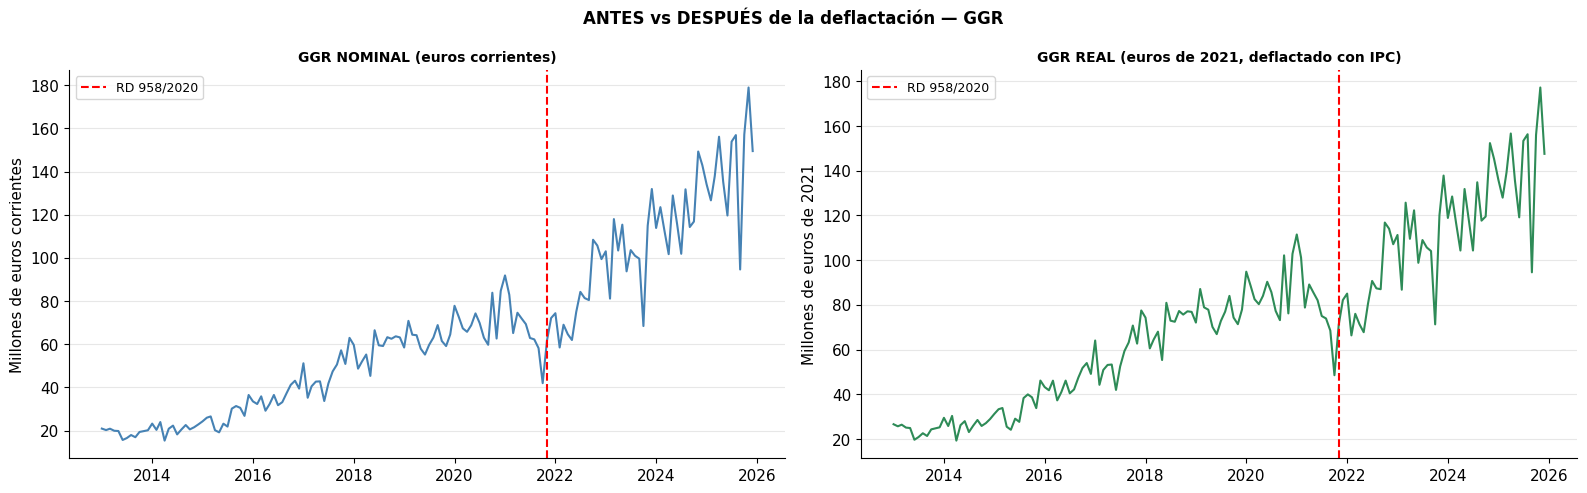

Interpretacion:
  La diferencia entre ambas series refleja la inflacion acumulada.
  El periodo 2021-2024 registró inflacion elevada en España (pico
  10.8% en julio 2022), lo que hace que el GGR nominal aparente
  mayor actividad de la real. Trabajar con GGR real elimina este sesgo.


In [17]:
# CELDA 17 — ANTES vs DESPUÉS: deflactación del GGR
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ANTES vs DESPUÉS de la deflactación — GGR',
             fontsize=12, fontweight='bold')

axes[0].plot(df_master['Fecha'], df_master['GGR_Total']/1e6,
             color='steelblue', linewidth=1.5)
axes[0].axvline(FECHA_DECRETO, color='red', linestyle='--', linewidth=1.5, label='RD 958/2020')
axes[0].set_title('GGR NOMINAL (euros corrientes)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Millones de euros corrientes')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(df_master['Fecha'], df_master['GGR_real']/1e6,
             color='seagreen', linewidth=1.5)
axes[1].axvline(FECHA_DECRETO, color='red', linestyle='--', linewidth=1.5, label='RD 958/2020')
axes[1].set_title('GGR REAL (euros de 2021, deflactado con IPC)', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Millones de euros de 2021')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('antes_despues_deflactacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretacion:')
print('  La diferencia entre ambas series refleja la inflacion acumulada.')
print('  El periodo 2021-2024 registró inflacion elevada en España (pico')
print('  10.8% en julio 2022), lo que hace que el GGR nominal aparente')
print('  mayor actividad de la real. Trabajar con GGR real elimina este sesgo.')

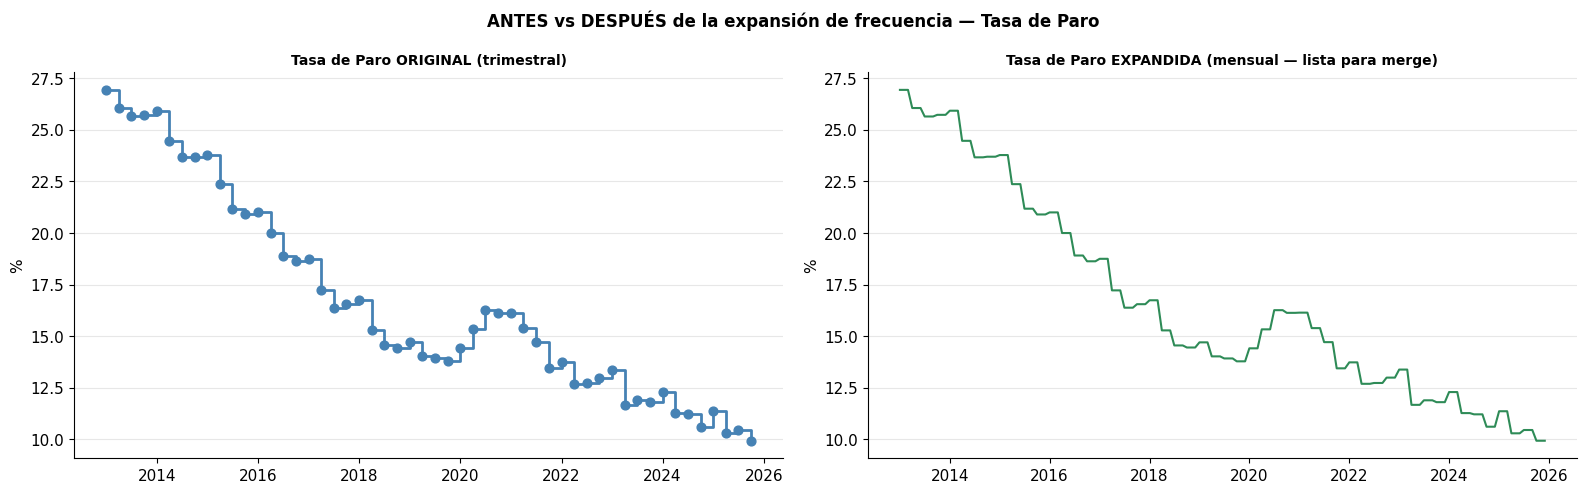

Interpretacion:
  La expansion mantiene el valor del trimestre en sus 3 meses.
  Es la tecnica estandar en econometria para variables de control
  de baja frecuencia en modelos de alta frecuencia.


In [18]:
# CELDA 18 — ANTES vs DESPUÉS: expansión de frecuencia (tasa de paro)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ANTES vs DESPUÉS de la expansión de frecuencia — Tasa de Paro',
             fontsize=12, fontweight='bold')

axes[0].step(paro_clean['Fecha_trim'], paro_clean['Tasa_paro'],
             color='steelblue', linewidth=2, where='post')
axes[0].scatter(paro_clean['Fecha_trim'], paro_clean['Tasa_paro'],
                color='steelblue', s=40, zorder=5)
axes[0].set_title('Tasa de Paro ORIGINAL (trimestral)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('%'); axes[0].grid(axis='y', alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(paro_mensual['Fecha'], paro_mensual['Tasa_paro'],
             color='seagreen', linewidth=1.5)
axes[1].set_title('Tasa de Paro EXPANDIDA (mensual — lista para merge)',
                  fontsize=10, fontweight='bold')
axes[1].set_ylabel('%'); axes[1].grid(axis='y', alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('antes_despues_expansion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretacion:')
print('  La expansion mantiene el valor del trimestre en sus 3 meses.')
print('  Es la tecnica estandar en econometria para variables de control')
print('  de baja frecuencia en modelos de alta frecuencia.')

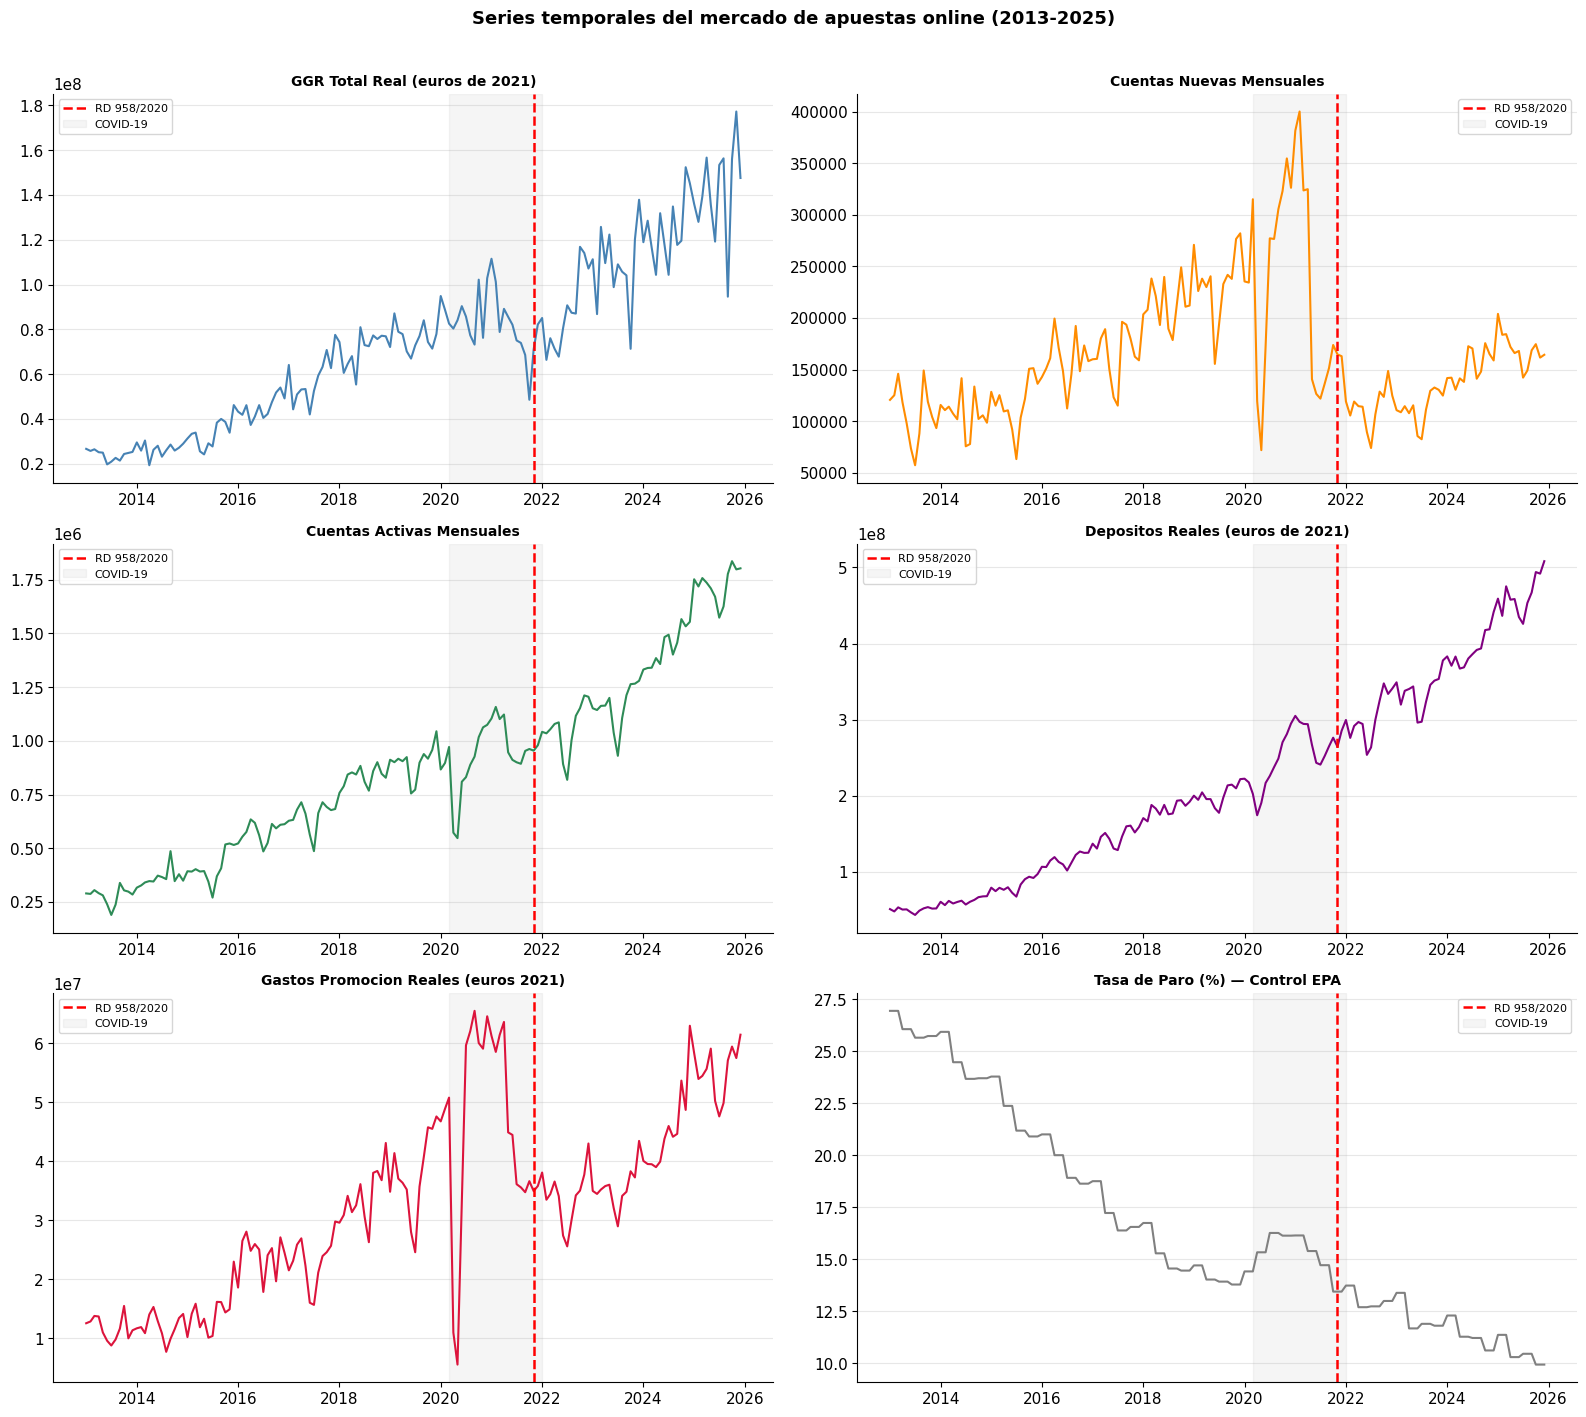

In [19]:
# CELDA 19 — Series temporales con punto de quiebre
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Series temporales del mercado de apuestas online (2013-2025)',
             fontsize=13, fontweight='bold', y=1.01)

series_plot = [
    ('GGR_real',        'GGR Total Real (euros de 2021)',       'steelblue'),
    ('Cuentas nuevas',  'Cuentas Nuevas Mensuales',             'darkorange'),
    ('Cuentas activas', 'Cuentas Activas Mensuales',            'seagreen'),
    ('Depositos_real',  'Depositos Reales (euros de 2021)',     'purple'),
    ('Gastos_real',     'Gastos Promocion Reales (euros 2021)', 'crimson'),
    ('Tasa_paro',       'Tasa de Paro (%) — Control EPA',       'gray'),
]

for ax, (col, titulo, color) in zip(axes.flat, series_plot):
    if col not in df_master.columns:
        ax.set_visible(False); continue
    ax.plot(df_master['Fecha'], df_master[col], color=color, linewidth=1.5)
    ax.axvline(FECHA_DECRETO, color='red', linestyle='--', linewidth=1.8, label='RD 958/2020')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
               alpha=0.08, color='gray', label='COVID-19')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('series_temporales_decreto.png', dpi=150, bbox_inches='tight')
plt.show()

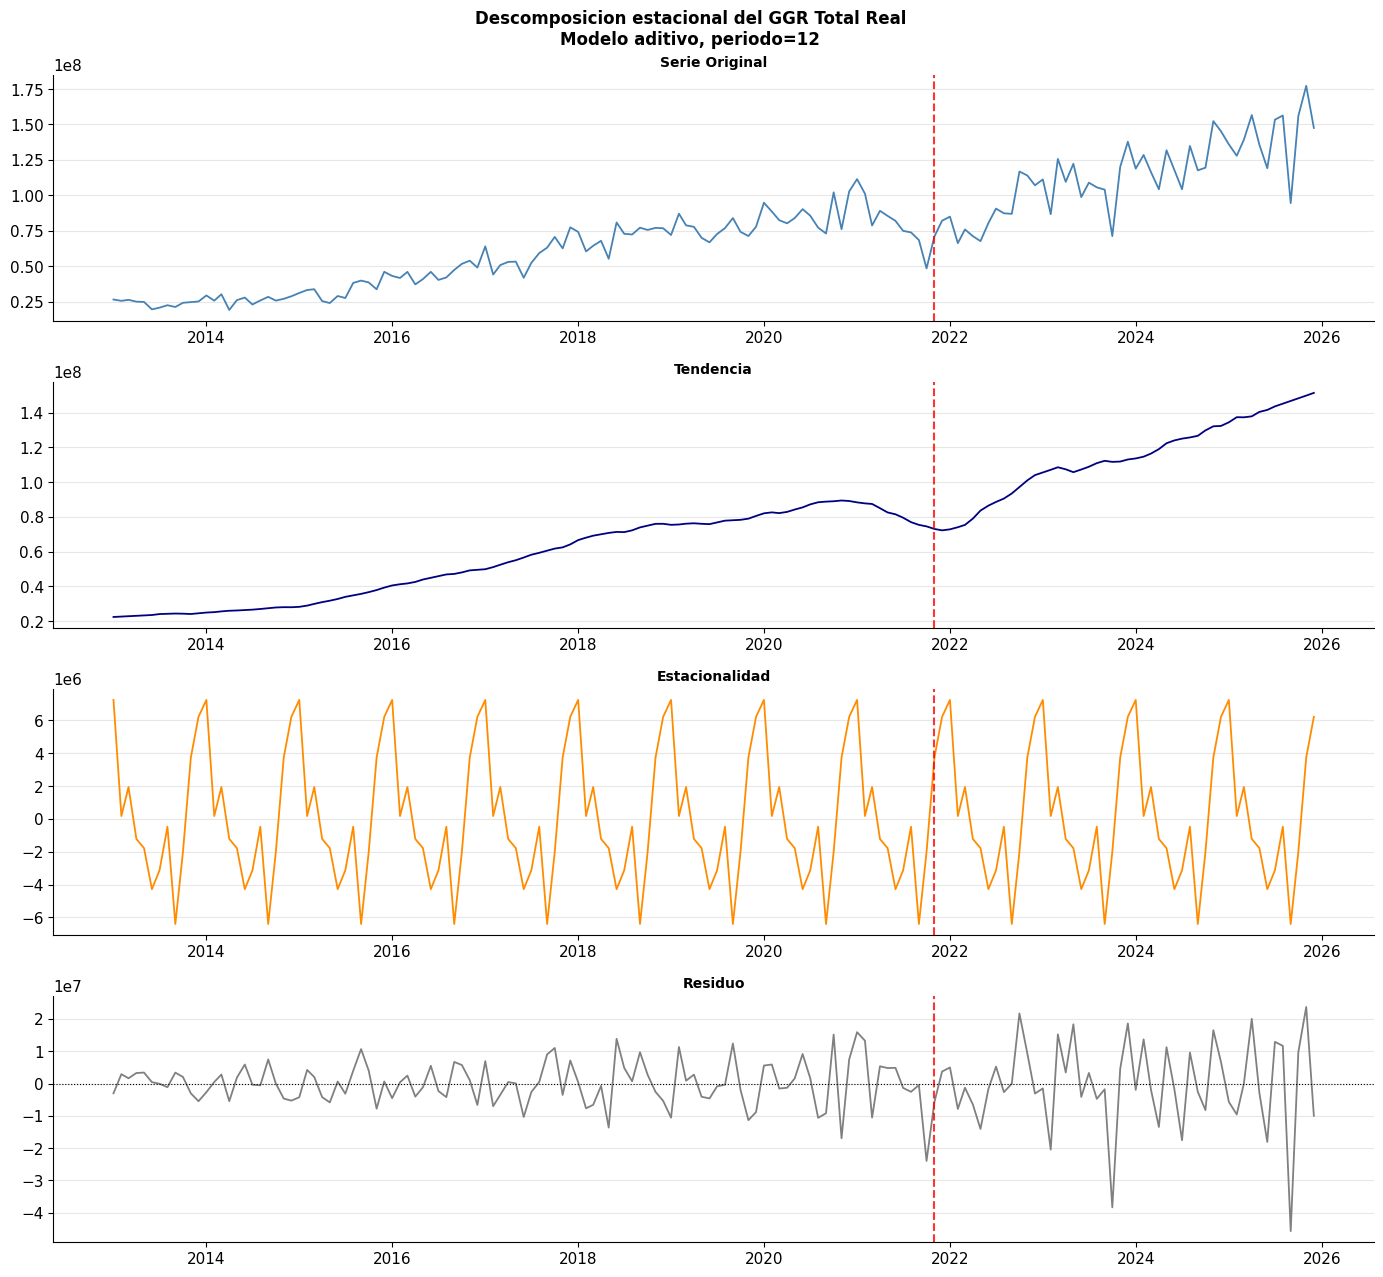

Interpretacion de componentes:
  TENDENCIA: crecimiento 2013-2020 -> caida COVID -> recuperacion 2021
             -> inflexion visible desde nov 2021 (decreto).
             Esta inflexion en la tendencia es la huella visual del
             efecto que el modelo SARIMAX cuantificara causalmente.
  ESTACIONALIDAD: patron anual estable con maximo en sep-dic
             (temporada futbolistica) y minimo en agosto (paron ligas).
             Amplitud aproximadamente constante -> justifica modelo aditivo.
  RESIDUO: si el modelo capta bien la tendencia y estacionalidad,
           el residuo deberia ser ruido blanco. El cambio visible
           en el residuo desde nov 2021 indica que hay un efecto
           estructural que el componente de tendencia no absorbe.


In [20]:
# CELDA 20 — Descomposición estacional
# Justificacion del modelo aditivo:
# Se elige el modelo aditivo (y_t = T_t + S_t + R_t) frente al
# multiplicativo (y_t = T_t * S_t * R_t) porque la amplitud de
# la estacionalidad del GGR permanece aproximadamente constante
# a lo largo del tiempo, independientemente del nivel de la serie.
# Si la amplitud creciera proporcionalmente con el nivel (ej: el
# pico de diciembre es siempre el 20% mayor que la media), el
# modelo multiplicativo seria el correcto. El analisis visual
# confirma que la diferencia entre el maximo y el minimo estacional
# es relativamente estable incluso cuando el nivel del GGR crece,
# lo que justifica el modelo aditivo.

ggr_serie = df_master.set_index('Fecha')['GGR_real'].copy()
result = seasonal_decompose(ggr_serie, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 13))
fig.suptitle('Descomposicion estacional del GGR Total Real\nModelo aditivo, periodo=12',
             fontsize=12, fontweight='bold')

comps = [
    (ggr_serie,       'Serie Original',  'steelblue'),
    (result.trend,    'Tendencia',       'navy'),
    (result.seasonal, 'Estacionalidad',  'darkorange'),
    (result.resid,    'Residuo',         'gray'),
]
for ax, (serie, titulo, color) in zip(axes, comps):
    ax.plot(serie.index, serie.values, color=color, linewidth=1.3)
    ax.axvline(FECHA_DECRETO, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(axis='y', alpha=0.3)
    if titulo == 'Residuo':
        ax.axhline(0, color='black', linewidth=0.8, linestyle=':')

plt.tight_layout()
plt.savefig('descomposicion_estacional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretacion de componentes:')
print('  TENDENCIA: crecimiento 2013-2020 -> caida COVID -> recuperacion 2021')
print('             -> inflexion visible desde nov 2021 (decreto).')
print('             Esta inflexion en la tendencia es la huella visual del')
print('             efecto que el modelo SARIMAX cuantificara causalmente.')
print('  ESTACIONALIDAD: patron anual estable con maximo en sep-dic')
print('             (temporada futbolistica) y minimo en agosto (paron ligas).')
print('             Amplitud aproximadamente constante -> justifica modelo aditivo.')
print('  RESIDUO: si el modelo capta bien la tendencia y estacionalidad,')
print('           el residuo deberia ser ruido blanco. El cambio visible')
print('           en el residuo desde nov 2021 indica que hay un efecto')
print('           estructural que el componente de tendencia no absorbe.')

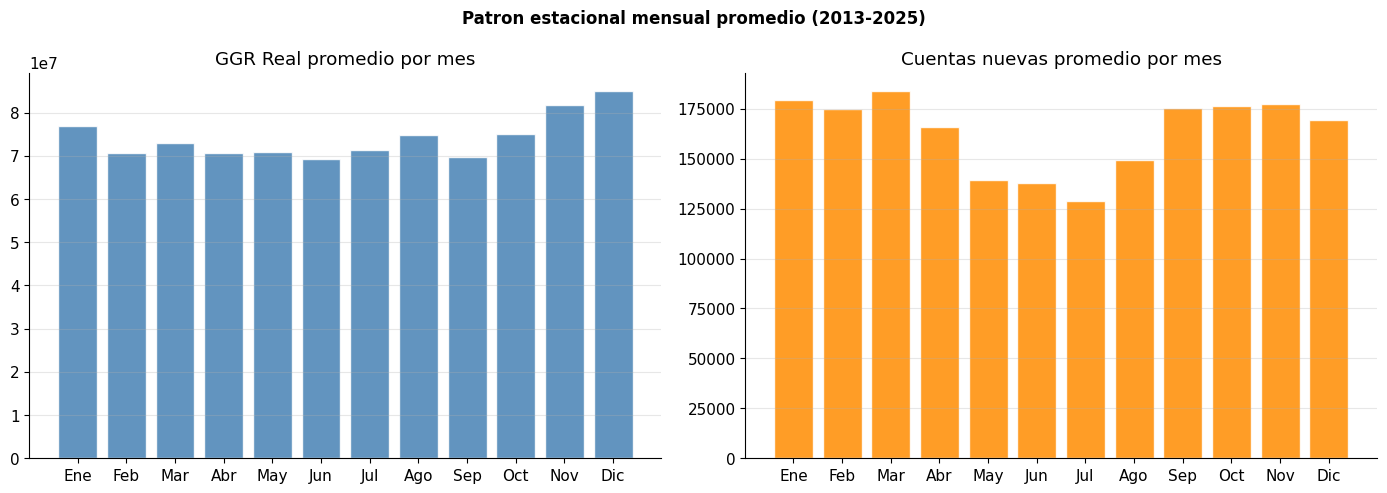

  Mes de mayor GGR: Dic
  Mes de menor GGR: Jun

  Interpretacion: el patron confirma que la demanda de apuestas
  esta fuertemente vinculada al calendario futbolistico. Agosto
  (paron de ligas) es consistentemente el mes de menor actividad.
  Este patron estacional con s=12 debe incluirse en el modelo SARIMAX
  para no confundirlo con el efecto del decreto.


In [21]:
# CELDA 21 — Patron estacional mensual
df_master['Mes_n'] = df_master['Fecha'].dt.month
nombres_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Patron estacional mensual promedio (2013-2025)', fontsize=12, fontweight='bold')

ggr_mes = df_master.groupby('Mes_n')['GGR_real'].mean()
axes[0].bar(range(1,13), ggr_mes.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(nombres_meses)
axes[0].set_title('GGR Real promedio por mes'); axes[0].grid(axis='y', alpha=0.3)

ct_mes = df_master.groupby('Mes_n')['Cuentas nuevas'].mean()
axes[1].bar(range(1,13), ct_mes.values, color='darkorange', alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(nombres_meses)
axes[1].set_title('Cuentas nuevas promedio por mes'); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('patron_estacional.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Mes de mayor GGR: {nombres_meses[ggr_mes.idxmax()-1]}')
print(f'  Mes de menor GGR: {nombres_meses[ggr_mes.idxmin()-1]}')
print()
print('  Interpretacion: el patron confirma que la demanda de apuestas')
print('  esta fuertemente vinculada al calendario futbolistico. Agosto')
print('  (paron de ligas) es consistentemente el mes de menor actividad.')
print('  Este patron estacional con s=12 debe incluirse en el modelo SARIMAX')
print('  para no confundirlo con el efecto del decreto.')

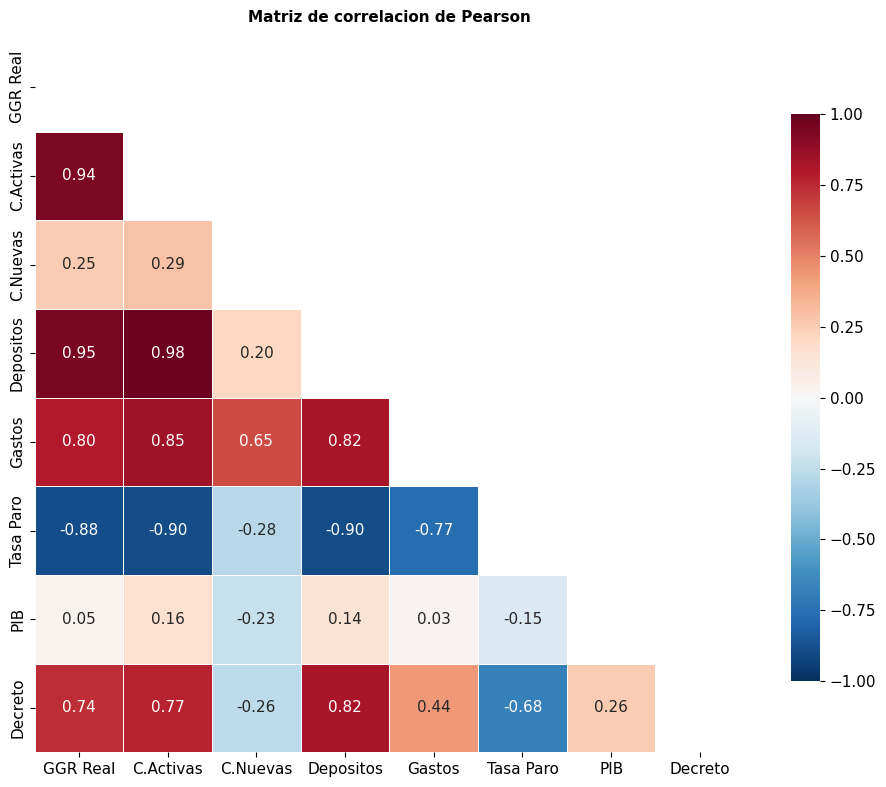

ANÁLISIS DE MULTICOLINEALIDAD (|r| > 0.7)
  GGR Real — C.Activas: r = 0.938 (ALTA (|r|>0.9))
  GGR Real — Depositos: r = 0.949 (ALTA (|r|>0.9))
  GGR Real — Gastos: r = 0.800 (MODERADA (0.7<|r|<0.9))
  GGR Real — Tasa Paro: r = -0.884 (MODERADA (0.7<|r|<0.9))
  GGR Real — Decreto: r = 0.737 (MODERADA (0.7<|r|<0.9))
  C.Activas — Depositos: r = 0.984 (ALTA (|r|>0.9))
  C.Activas — Gastos: r = 0.850 (MODERADA (0.7<|r|<0.9))
  C.Activas — Tasa Paro: r = -0.898 (MODERADA (0.7<|r|<0.9))
  C.Activas — Decreto: r = 0.768 (MODERADA (0.7<|r|<0.9))
  Depositos — Gastos: r = 0.821 (MODERADA (0.7<|r|<0.9))
  Depositos — Tasa Paro: r = -0.897 (MODERADA (0.7<|r|<0.9))
  Depositos — Decreto: r = 0.821 (MODERADA (0.7<|r|<0.9))
  Gastos — Tasa Paro: r = -0.765 (MODERADA (0.7<|r|<0.9))

  Interpretacion: la alta correlacion entre variables de apuestas
  (GGR, Depositos, Gastos) refleja que todas miden aspectos del
  mismo fenomeno — la actividad del mercado. En el modelo SARIMAX
  se usara GGR_real como

In [22]:
# CELDA 22 — Matriz de correlacion con análisis de multicolinealidad
vars_c = ['GGR_real','Cuentas activas','Cuentas nuevas',
          'Depositos_real','Gastos_real','Tasa_paro','PIB_var_anual','decreto']
vars_c = [v for v in vars_c if v in df_master.columns]
labels = ['GGR Real','C.Activas','C.Nuevas','Depositos',
          'Gastos','Tasa Paro','PIB','Decreto'][:len(vars_c)]

corr = df_master[vars_c].corr()
corr_display = corr.copy()
corr_display.index = labels; corr_display.columns = labels

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_display, dtype=bool))
sns.heatmap(corr_display, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink':0.8})
ax.set_title('Matriz de correlacion de Pearson', fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('ANÁLISIS DE MULTICOLINEALIDAD (|r| > 0.7)')
print('='*60)
corr_vals = corr.copy()
np.fill_diagonal(corr_vals.values, 0)
altas = []
for i in range(len(vars_c)):
    for j in range(i+1, len(vars_c)):
        r = corr_vals.iloc[i,j]
        if abs(r) > 0.7:
            altas.append((labels[i], labels[j], r))

if altas:
    for v1, v2, r in altas:
        nivel = 'ALTA (|r|>0.9)' if abs(r) > 0.9 else 'MODERADA (0.7<|r|<0.9)'
        print(f'  {v1} — {v2}: r = {r:.3f} ({nivel})')
    print()
    print('  Interpretacion: la alta correlacion entre variables de apuestas')
    print('  (GGR, Depositos, Gastos) refleja que todas miden aspectos del')
    print('  mismo fenomeno — la actividad del mercado. En el modelo SARIMAX')
    print('  se usara GGR_real como variable dependiente y Tasa_paro y PIB')
    print('  como unicas variables exogenas para evitar multicolinealidad.')
else:
    print('  No se detecta multicolinealidad relevante entre las variables.')

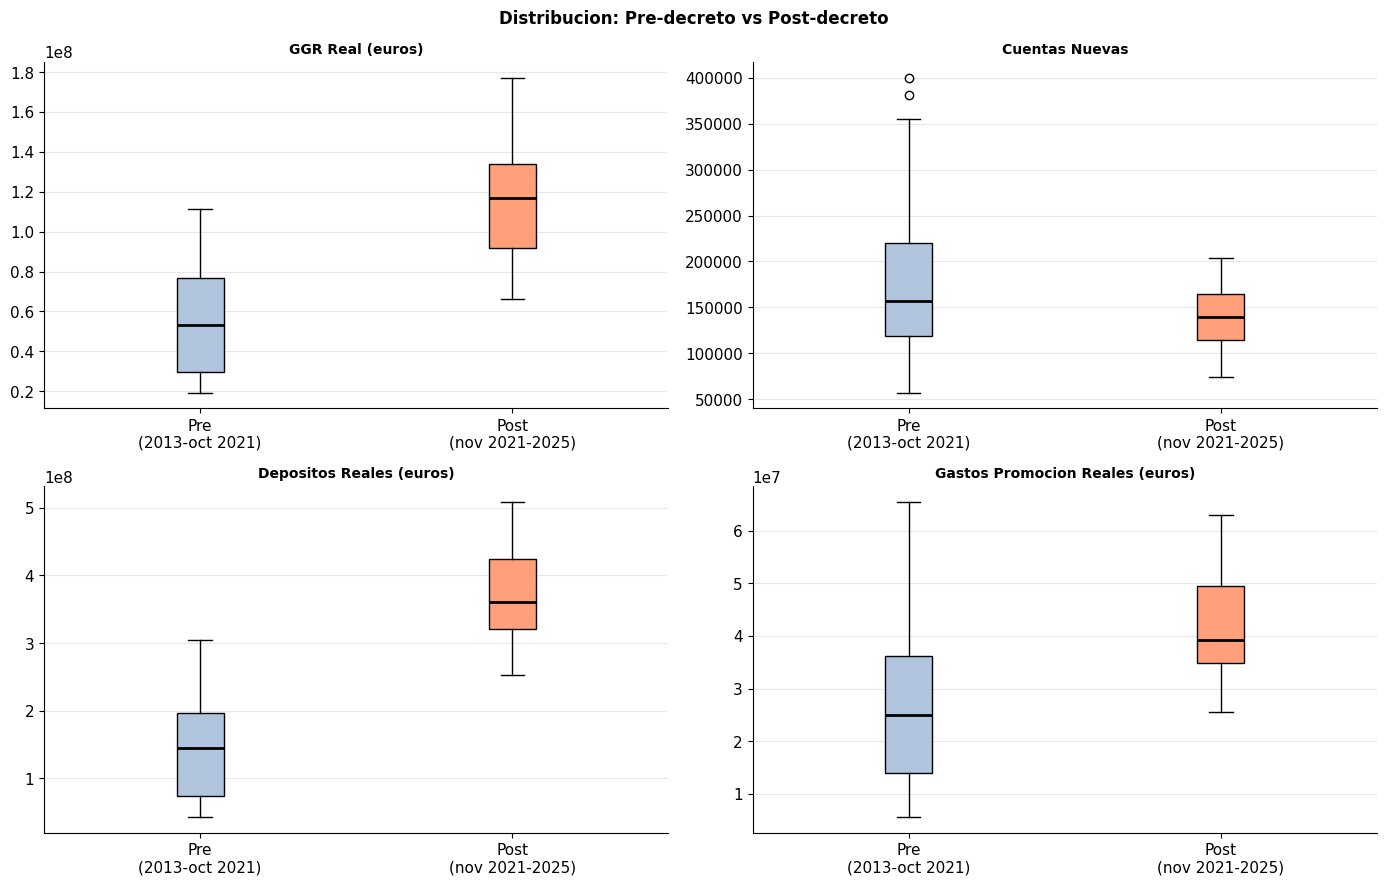

In [23]:
# CELDA 23 — Boxplot pre vs post decreto
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribucion: Pre-decreto vs Post-decreto', fontsize=12, fontweight='bold')

vars_box = [
    ('GGR_real','GGR Real (euros)'),
    ('Cuentas nuevas','Cuentas Nuevas'),
    ('Depositos_real','Depositos Reales (euros)'),
    ('Gastos_real','Gastos Promocion Reales (euros)'),
]
for ax, (col, titulo) in zip(axes.flat, vars_box):
    if col not in df_master.columns: continue
    pre  = df_master[df_master['decreto']==0][col]
    post = df_master[df_master['decreto']==1][col]
    bp = ax.boxplot([pre, post],
                    labels=['Pre\n(2013-oct 2021)', 'Post\n(nov 2021-2025)'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('lightsteelblue')
    bp['boxes'][1].set_facecolor('lightsalmon')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_pre_post.png', dpi=150, bbox_inches='tight')
plt.show()

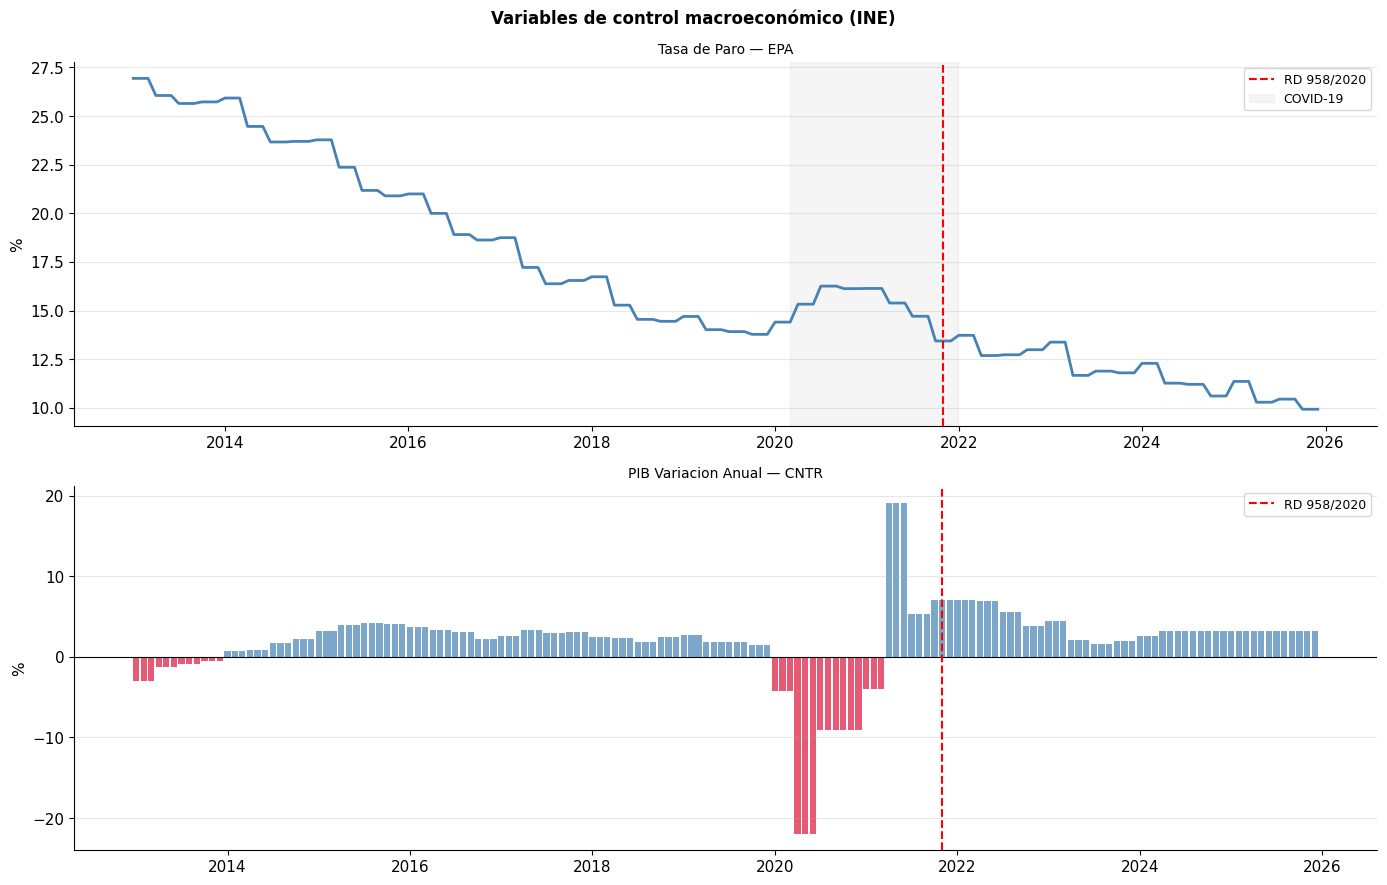

In [24]:
# CELDA 24 — Variables de control macroeconómico
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Variables de control macroeconómico (INE)', fontsize=12, fontweight='bold')

axes[0].plot(df_master['Fecha'], df_master['Tasa_paro'], color='steelblue', linewidth=2)
axes[0].axvline(FECHA_DECRETO, color='red', linestyle='--', linewidth=1.5, label='RD 958/2020')
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
                alpha=0.08, color='gray', label='COVID-19')
axes[0].set_title('Tasa de Paro — EPA', fontsize=10)
axes[0].set_ylabel('%'); axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

colors = df_master['PIB_var_anual'].apply(lambda x: 'steelblue' if x >= 0 else 'crimson')
axes[1].bar(df_master['Fecha'], df_master['PIB_var_anual'], color=colors, alpha=0.7, width=25)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(FECHA_DECRETO, color='red', linestyle='--', linewidth=1.5, label='RD 958/2020')
axes[1].set_title('PIB Variacion Anual — CNTR', fontsize=10)
axes[1].set_ylabel('%'); axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('variables_control.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Test de Estacionariedad (ADF) y Análisis de Autocorrelación (ACF/PACF)

### Justificación de esta sección

Esta sección es el puente entre la ingeniería del dato y el modelado. Los resultados aquí obtenidos determinan directamente la especificación del modelo SARIMAX:

- **Test ADF → parámetro `d`:** si la serie es estacionaria en niveles, `d=0`. Si requiere una diferenciación, `d=1`.
- **ACF → parámetro `q`:** el número de retardos significativos en la función de autocorrelación indica el orden del componente MA.
- **PACF → parámetro `p`:** el número de retardos significativos en la autocorrelación parcial indica el orden del componente AR.

### El Test de Dickey-Fuller Aumentado (ADF)

El ADF contrasta la hipótesis nula de que la serie tiene una raíz unitaria (es decir, que NO es estacionaria). Si el p-valor es inferior a 0.05, rechazamos H₀ y concluimos que la serie es estacionaria. Si el p-valor ≥ 0.05, la serie tiene raíz unitaria y debemos diferenciarla.

### Los gráficos ACF y PACF

La **función de autocorrelación (ACF)** muestra la correlación entre la serie y sus valores retardados. Un corte abrupto en el retardo `q` indica un proceso MA(q).

La **función de autocorrelación parcial (PACF)** muestra la correlación entre la serie y sus retardos después de eliminar el efecto de los retardos intermedios. Un corte abrupto en el retardo `p` indica un proceso AR(p).

En series estacionales, se observan picos significativos también en los retardos múltiplos de 12 (retardos 12, 24...), lo que indica la necesidad de los componentes estacionales P, D, Q.

In [25]:
# CELDA 25 — Test ADF para las variables principales
def test_adf(serie, nombre, alpha=0.05):
    s = pd.to_numeric(serie, errors='coerce').dropna()
    resultado  = adfuller(s, autolag='AIC')
    adf_stat   = resultado[0]
    p_valor    = resultado[1]
    n_lags     = resultado[2]
    vals_crit  = resultado[4]
    estacionaria = p_valor < alpha
    simbolo = '✅' if estacionaria else '⚠️ '
    conclusion = 'ESTACIONARIA (d=0)' if estacionaria else 'NO ESTACIONARIA → diferenciacion necesaria (d≥1)'
    print(f'{simbolo} {nombre}')
    print(f'   ADF stat: {adf_stat:.4f} | p-valor: {p_valor:.4f} | Lags: {n_lags}')
    print(f'   Valores criticos: 1%={vals_crit["1%"]:.3f} | 5%={vals_crit["5%"]:.3f} | 10%={vals_crit["10%"]:.3f}')
    print(f'   → {conclusion}')
    print()
    return {'variable':nombre,'adf':round(adf_stat,4),'p_valor':round(p_valor,4),'estacionaria':estacionaria}

print('TEST DE DICKEY-FULLER AUMENTADO (ADF)')
print('H0: la serie tiene raiz unitaria (NO estacionaria)')
print('H1: la serie es estacionaria | alpha = 0.05')
print('='*65)
print()

vars_adf = [
    ('GGR_real','GGR Total Real'),
    ('Cuentas nuevas','Cuentas Nuevas'),
    ('Cuentas activas','Cuentas Activas'),
    ('Depositos_real','Depositos Reales'),
    ('Gastos_real','Gastos de Promocion Reales'),
    ('Tasa_paro','Tasa de Paro'),
    ('PIB_var_anual','PIB Variacion Anual'),
]
resultados_adf = []
for col, nombre in vars_adf:
    if col in df_master.columns:
        resultados_adf.append(test_adf(df_master[col], nombre))

df_adf = pd.DataFrame(resultados_adf)
print('RESUMEN')
display(df_adf)

TEST DE DICKEY-FULLER AUMENTADO (ADF)
H0: la serie tiene raiz unitaria (NO estacionaria)
H1: la serie es estacionaria | alpha = 0.05

⚠️  GGR Total Real
   ADF stat: 0.6872 | p-valor: 0.9896 | Lags: 10
   Valores criticos: 1%=-3.476 | 5%=-2.882 | 10%=-2.578
   → NO ESTACIONARIA → diferenciacion necesaria (d≥1)

✅ Cuentas Nuevas
   ADF stat: -3.6702 | p-valor: 0.0046 | Lags: 0
   Valores criticos: 1%=-3.473 | 5%=-2.880 | 10%=-2.577
   → ESTACIONARIA (d=0)

⚠️  Cuentas Activas
   ADF stat: 1.4932 | p-valor: 0.9975 | Lags: 10
   Valores criticos: 1%=-3.476 | 5%=-2.882 | 10%=-2.578
   → NO ESTACIONARIA → diferenciacion necesaria (d≥1)

⚠️  Depositos Reales
   ADF stat: 1.9186 | p-valor: 0.9986 | Lags: 14
   Valores criticos: 1%=-3.478 | 5%=-2.882 | 10%=-2.578
   → NO ESTACIONARIA → diferenciacion necesaria (d≥1)

⚠️  Gastos de Promocion Reales
   ADF stat: -1.8644 | p-valor: 0.3490 | Lags: 2
   Valores criticos: 1%=-3.474 | 5%=-2.881 | 10%=-2.577
   → NO ESTACIONARIA → diferenciacion neces

,variable,adf,p_valor,estacionaria
0,GGR Total Real,0.6872,0.9896,False
1,Cuentas Nuevas,-3.6702,0.0046,True
2,Cuentas Activas,1.4932,0.9975,False
3,Depositos Reales,1.9186,0.9986,False
4,Gastos de Promocion Reales,-1.8644,0.3490,False
5,Tasa de Paro,-2.2196,0.1992,False
6,PIB Variacion Anual,-2.8532,0.0511,False


In [26]:
# CELDA 26 — Test ADF en primeras diferencias
no_estacionarias = [r for r in resultados_adf if not r['estacionaria']]

if no_estacionarias:
    print('TEST ADF EN PRIMERAS DIFERENCIAS')
    print('(series no estacionarias en niveles)')
    print('='*65)
    print()
    resultados_diff = []
    for r in no_estacionarias:
        col_orig = [c for c, n in vars_adf if n == r['variable']]
        if col_orig:
            serie_diff = df_master[col_orig[0]].diff().dropna()
            r_diff = test_adf(serie_diff, f'{r["variable"]} (1ª diferencia)')
            resultados_diff.append(r_diff)

    print('='*65)
    print('IMPLICACIONES PARA EL MODELO SARIMAX:')
    print()
    for r in resultados_diff:
        nombre = r['variable'].replace(' (1ª diferencia)','')
        if r['estacionaria']:
            print(f'  {nombre}: I(1) → d=1 en el modelo ARIMA')
        else:
            print(f'  {nombre}: puede ser I(2) → verificar en modelado')
    print()
    print('  Nota: para variables con d=1, el modelo SARIMAX incluira')
    print('  el parametro de diferenciacion d=1 en su especificacion.')
else:
    print('Todas las series son estacionarias en niveles (d=0).')

TEST ADF EN PRIMERAS DIFERENCIAS
(series no estacionarias en niveles)

✅ GGR Total Real (1ª diferencia)
   ADF stat: -6.0844 | p-valor: 0.0000 | Lags: 9
   Valores criticos: 1%=-3.476 | 5%=-2.882 | 10%=-2.578
   → ESTACIONARIA (d=0)

✅ Cuentas Activas (1ª diferencia)
   ADF stat: -12.0113 | p-valor: 0.0000 | Lags: 1
   Valores criticos: 1%=-3.474 | 5%=-2.881 | 10%=-2.577
   → ESTACIONARIA (d=0)

✅ Depositos Reales (1ª diferencia)
   ADF stat: -2.9488 | p-valor: 0.0400 | Lags: 13
   Valores criticos: 1%=-3.478 | 5%=-2.882 | 10%=-2.578
   → ESTACIONARIA (d=0)

✅ Gastos de Promocion Reales (1ª diferencia)
   ADF stat: -6.6864 | p-valor: 0.0000 | Lags: 7
   Valores criticos: 1%=-3.476 | 5%=-2.881 | 10%=-2.577
   → ESTACIONARIA (d=0)

✅ Tasa de Paro (1ª diferencia)
   ADF stat: -2.9818 | p-valor: 0.0366 | Lags: 14
   Valores criticos: 1%=-3.478 | 5%=-2.882 | 10%=-2.578
   → ESTACIONARIA (d=0)

✅ PIB Variacion Anual (1ª diferencia)
   ADF stat: -5.0495 | p-valor: 0.0000 | Lags: 11
   Valores

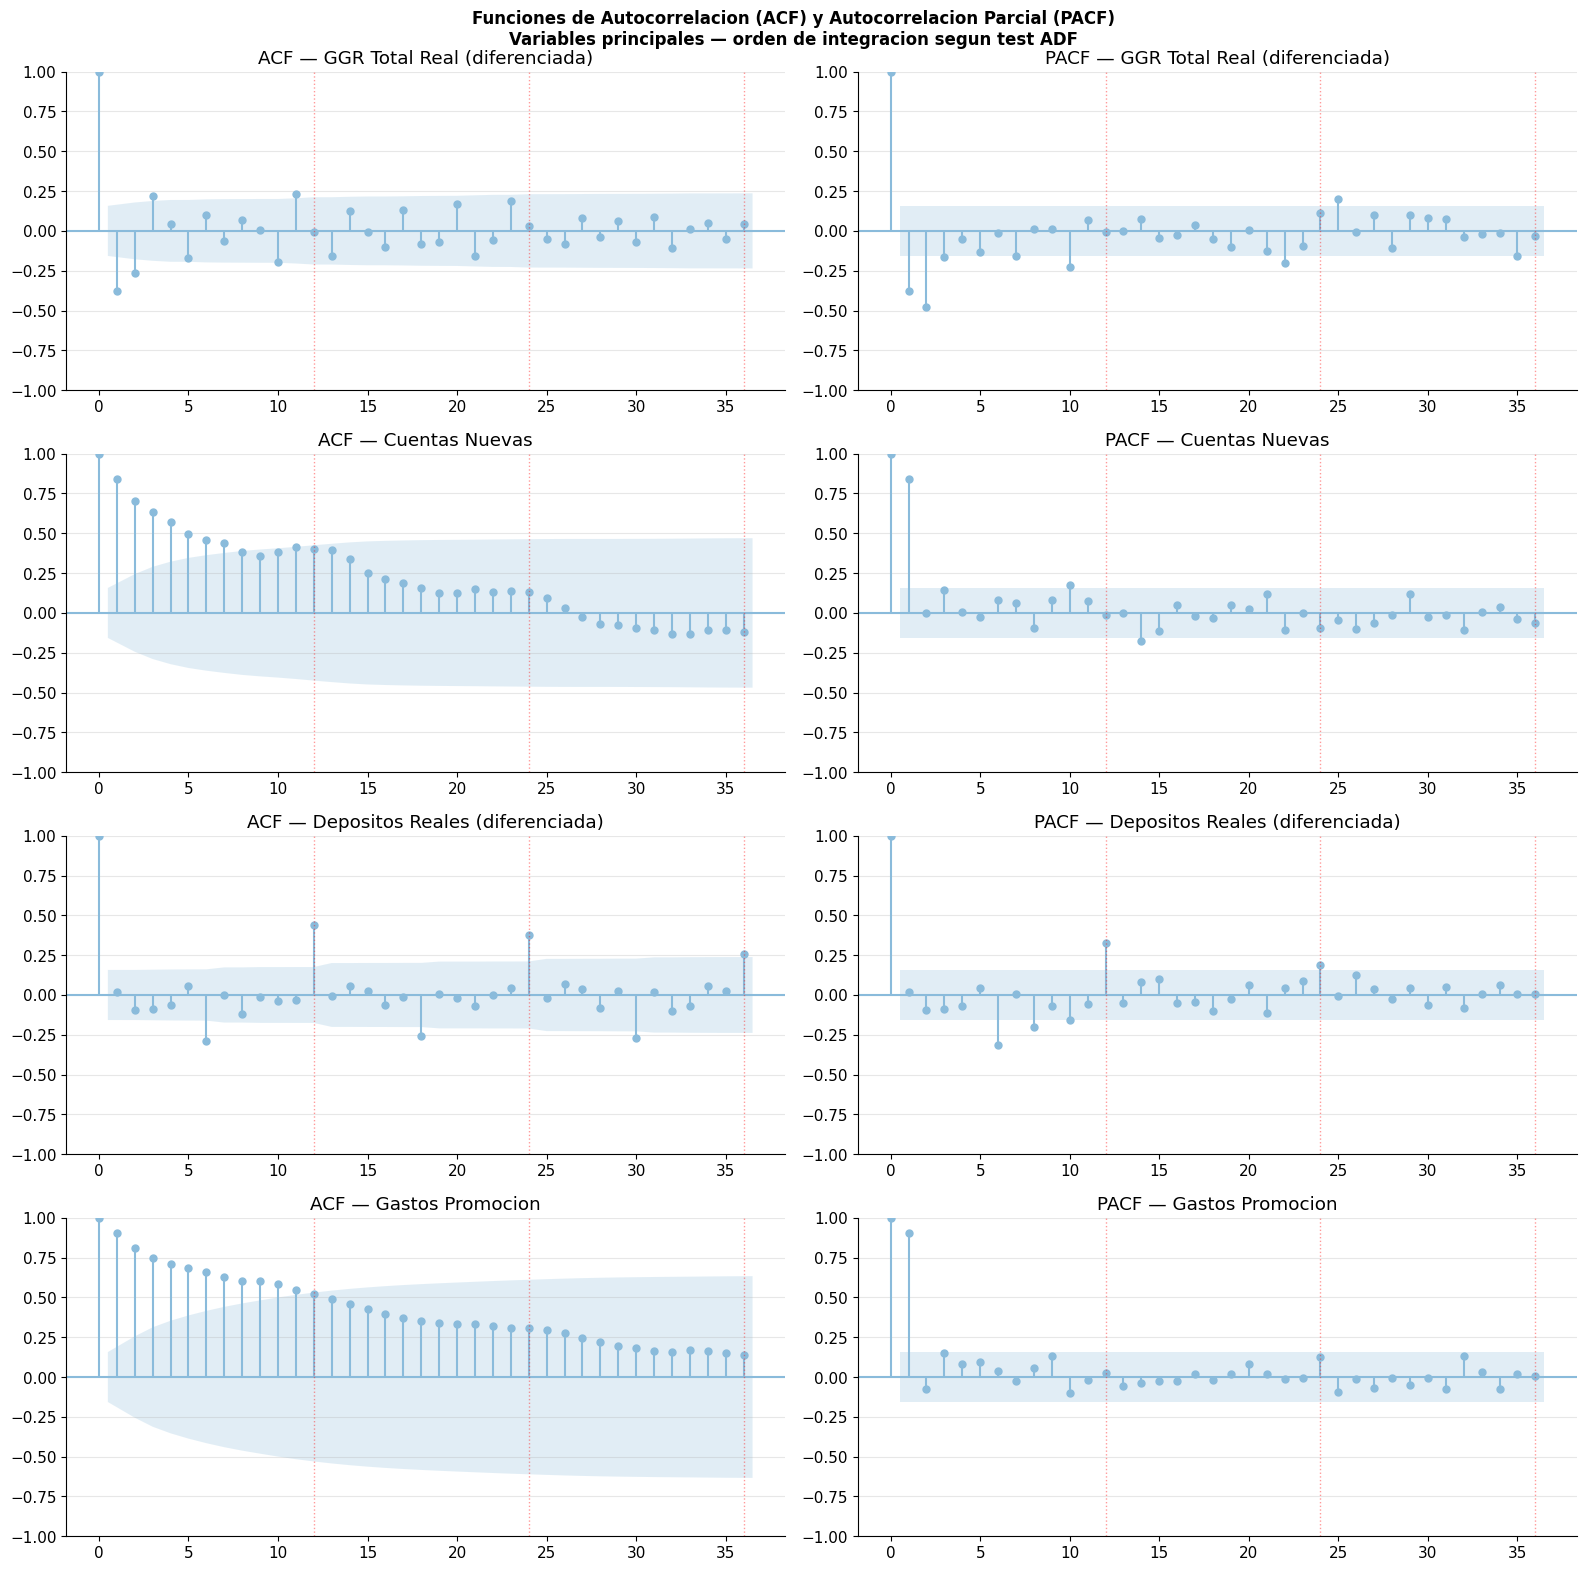

Interpretacion de ACF/PACF:
  - Picos significativos en ACF en retardos 1,2,... -> componente MA(q)
  - Picos significativos en PACF en retardos 1,2,... -> componente AR(p)
  - Picos en retardos 12, 24 (lineas rojas punteadas) -> necesidad de
    componentes estacionales P, D, Q con s=12 en el modelo SARIMAX
  - Las bandas azules son los intervalos de confianza al 95%.
    Retardos fuera de las bandas son estadisticamente significativos.


In [27]:
# CELDA 27 — Gráficos ACF y PACF para las variables principales
# Los graficos ACF y PACF son fundamentales para identificar los
# ordenes p y q del modelo ARIMA. Se aplican a las series en el
# orden de integracion correcto segun los resultados del ADF.

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
fig.suptitle('Funciones de Autocorrelacion (ACF) y Autocorrelacion Parcial (PACF)\n'
             'Variables principales — orden de integracion segun test ADF',
             fontsize=12, fontweight='bold')

vars_acf = [
    ('GGR_real','GGR Total Real'),
    ('Cuentas nuevas','Cuentas Nuevas'),
    ('Depositos_real','Depositos Reales'),
    ('Gastos_real','Gastos Promocion'),
]
lags_mostrar = 36  # 3 años para capturar estacionalidad anual

for i, (col, nombre) in enumerate(vars_acf):
    if col not in df_master.columns: continue
    # Determinar si la serie es estacionaria o necesita diferenciacion
    es_estacionaria = next((r['estacionaria'] for r in resultados_adf
                           if col in r['variable'] or nombre in r['variable']), True)
    serie = df_master[col].diff().dropna() if not es_estacionaria else df_master[col]
    sufijo = ' (diferenciada)' if not es_estacionaria else ''

    ax_acf  = axes[i][0]
    ax_pacf = axes[i][1]

    plot_acf(serie,  lags=lags_mostrar, ax=ax_acf,  alpha=0.05, title=f'ACF — {nombre}{sufijo}')
    plot_pacf(serie, lags=lags_mostrar, ax=ax_pacf, alpha=0.05, title=f'PACF — {nombre}{sufijo}',
              method='ywm')

    # Marcar retardos estacionales
    for ax in [ax_acf, ax_pacf]:
        for lag_s in [12, 24, 36]:
            if lag_s <= lags_mostrar:
                ax.axvline(lag_s, color='red', linestyle=':', alpha=0.4, linewidth=1)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretacion de ACF/PACF:')
print('  - Picos significativos en ACF en retardos 1,2,... -> componente MA(q)')
print('  - Picos significativos en PACF en retardos 1,2,... -> componente AR(p)')
print('  - Picos en retardos 12, 24 (lineas rojas punteadas) -> necesidad de')
print('    componentes estacionales P, D, Q con s=12 en el modelo SARIMAX')
print('  - Las bandas azules son los intervalos de confianza al 95%.')
print('    Retardos fuera de las bandas son estadisticamente significativos.')

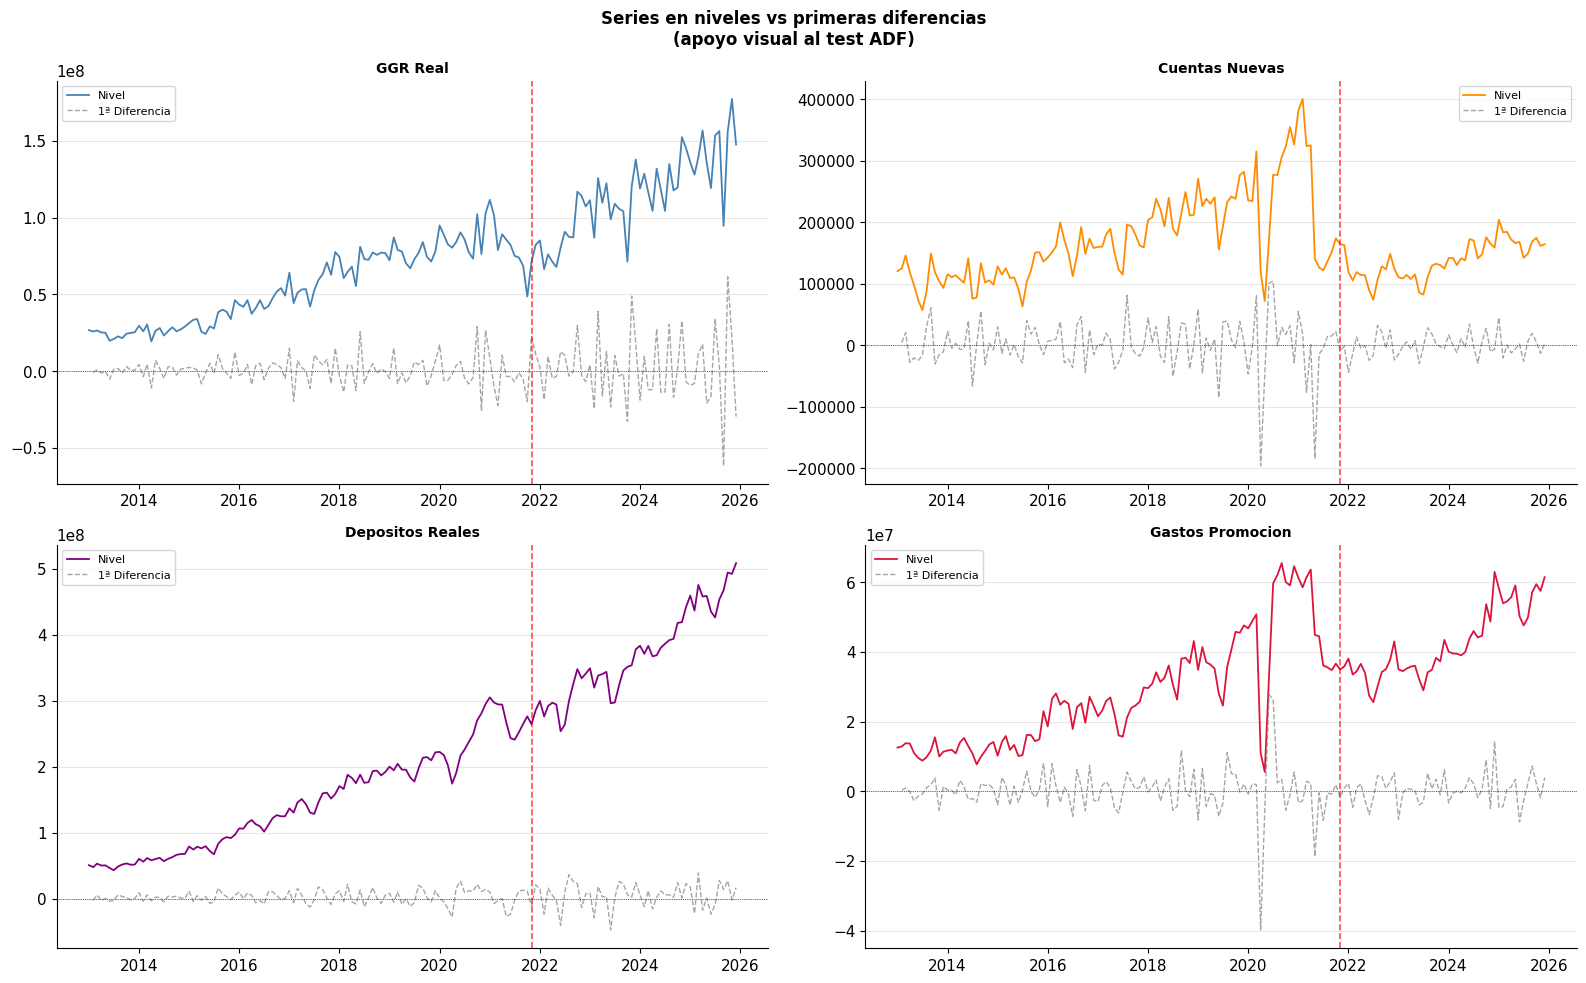

Si la primera diferencia (gris) fluctua alrededor de cero
sin tendencia visible -> la serie diferenciada es estacionaria -> d=1.


In [28]:
# CELDA 28 — Visualización: niveles vs primeras diferencias
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Series en niveles vs primeras diferencias\n(apoyo visual al test ADF)',
             fontsize=12, fontweight='bold')

pares = [('GGR_real','GGR Real'),('Cuentas nuevas','Cuentas Nuevas'),
         ('Depositos_real','Depositos Reales'),('Gastos_real','Gastos Promocion')]
colores = ['steelblue','darkorange','purple','crimson']

for i, ((col, nombre), color) in enumerate(zip(pares, colores)):
    if col not in df_master.columns: continue
    ax = axes[i//2][i%2]
    ax.plot(df_master['Fecha'], df_master[col], color=color, linewidth=1.3, label='Nivel')
    ax.plot(df_master['Fecha'], df_master[col].diff(), color='gray',
            linewidth=1, linestyle='--', alpha=0.7, label='1ª Diferencia')
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    ax.axvline(FECHA_DECRETO, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_title(nombre, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('niveles_vs_diferencias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Si la primera diferencia (gris) fluctua alrededor de cero')
print('sin tendencia visible -> la serie diferenciada es estacionaria -> d=1.')

---
## 7. Dataset maestro final

In [29]:
# CELDA 29 — Exportar dataset maestro
cols_f = [
    'Fecha','Año','Mes',
    'Cuentas activas','Cuentas nuevas',
    'Depósitos','Retiradas','Depositos_real',
    'GGR_Total','GGR_real','Cantidades_Total',
    'Publicidad','Bonos','Afiliados','Patrocinio','Total Gastos','Gastos_real',
    'IPC','Tasa_paro','PIB_var_anual',
    'decreto','covid'
]
cols_f = [c for c in cols_f if c in df_master.columns]
df_final = df_master[cols_f].copy()

print('DATASET MAESTRO FINAL')
print(f'  Dimensiones:        {df_final.shape[0]} filas x {df_final.shape[1]} columnas')
print(f'  Periodo:            {df_final["Fecha"].min().strftime("%B %Y")} a {df_final["Fecha"].max().strftime("%B %Y")}')
print(f'  Meses pre-decreto:  {(df_final["decreto"]==0).sum()}')
print(f'  Meses post-decreto: {(df_final["decreto"]==1).sum()}')
print(f'  Nulos totales:      {df_final.isnull().sum().sum()}')
print()
print('Variables incluidas:')
for col in df_final.columns:
    print(f'  • {col}')

display(df_final.head(5))
df_final.to_csv('dataset_maestro_TFG.csv', index=False, encoding='utf-8', sep=';', decimal=',')
print()
print('Exportado: dataset_maestro_TFG.csv — listo para modelado SARIMAX')

DATASET MAESTRO FINAL
  Dimensiones:        156 filas x 22 columnas
  Periodo:            January 2013 a December 2025
  Meses pre-decreto:  106
  Meses post-decreto: 50
  Nulos totales:      0

Variables incluidas:
  • Fecha
  • Año
  • Mes
  • Cuentas activas
  • Cuentas nuevas
  • Depósitos
  • Retiradas
  • Depositos_real
  • GGR_Total
  • GGR_real
  • Cantidades_Total
  • Publicidad
  • Bonos
  • Afiliados
  • Patrocinio
  • Total Gastos
  • Gastos_real
  • IPC
  • Tasa_paro
  • PIB_var_anual
  • decreto
  • covid


,Fecha,Año,Mes,Cuentas activas,Cuentas nuevas,Depósitos,Retiradas,Depositos_real,GGR_Total,GGR_real,...,Bonos,Afiliados,Patrocinio,Total Gastos,Gastos_real,IPC,Tasa_paro,PIB_var_anual,decreto,covid
0,2013-01-01,2013,Enero,289770,120555,39803786,20772330,5.057982e+07,20966725,2.664302e+07,...,2443546,1102163,266825,9868663,1.254039e+07,78.695,26.94,-2.9697,0,0
1,2013-02-01,2013,Febrero,287528,125069,37468821,19126090,4.752996e+07,20277768,2.572276e+07,...,3013126,1099009,219788,10125788,1.284477e+07,78.832,26.94,-2.9697,0,0
2,2013-03-01,2013,Marzo,305069,145874,41835683,22526521,5.288359e+07,20920774,2.644550e+07,...,3006975,909130,235332,10898538,1.377661e+07,79.109,26.94,-2.9697,0,0
3,2013-04-01,2013,Abril,290931,118272,39693634,21786590,4.998883e+07,19963714,2.514163e+07,...,2793074,1121471,222304,10867355,1.368598e+07,79.405,26.06,-1.2348,0,0
4,2013-05-01,2013,Mayo,280910,97914,39966205,22888871,5.023973e+07,19847994,2.495002e+07,...,2596839,987123,206306,8737126,1.098305e+07,79.551,26.06,-1.2348,0,0



Exportado: dataset_maestro_TFG.csv — listo para modelado SARIMAX


---
## 8. Conclusiones de la Ingeniería del Dato

### 8.1 Resumen del proceso

Se ha construido un dataset maestro mensual de **156 observaciones** (enero 2013 — diciembre 2025) integrando **tres fuentes oficiales** en **8 archivos** con formatos, encodings y frecuencias distintas.

| Etapa | Acciones realizadas | Criterio científico |
|---|---|---|
| Extracción | 8 archivos: CSV utf-8, CSV cp1252, XLSX | Fuentes oficiales DGOJ e INE |
| Limpieza | Eliminación de datos adelantados no publicados | Distinción entre nulo aleatorio y placeholder |
| Transformación | Deflactación, expansión trimestral→mensual, categorización | Homogeneización para análisis causal |
| Integración | Merge por Fecha, interpolación lineal residual | Continuidad de series temporales |
| Ingeniería de variables | `decreto`, `covid`, `GGR_real`, `Depositos_real` | Variables necesarias para el modelo |
| Verificación estadística | Test ADF + ACF/PACF | Especificación del modelo SARIMAX |

### 8.2 Variables incluidas y excluidas

**Incluidas:** GGR_real (dependiente principal), Cuentas nuevas, Cuentas activas, Depositos_real, Gastos_real (mecanismo del decreto), Tasa_paro y PIB_var_anual (controles macroeconómicos), decreto y covid (intervención y control).

**Excluidas con justificación:**
- *Datos xlsx histórico (CCAA/operador):* frecuencia anual no integrable en serie mensual sin supuestos de distribución que introducirían ruido.
- *Nº de depósitos (conteo):* redundante con depósitos en valor. La variable monetaria es más informativa para el análisis económico.
- *GGR por categoría como regresores:* alta correlación con GGR_Total genera multicolinealidad. Se reservan para modelos secundarios por segmento.

### 8.3 Hallazgos del EDA con implicaciones para el modelado

- **Estacionalidad confirmada** (s=12): máximos en septiembre-diciembre, mínimos en agosto. Necesidad de componentes estacionales P, D, Q en el SARIMAX.
- **Tendencia con inflexión post-decreto**: visible en el componente de tendencia de la descomposición estacional. El modelo debe capturar este cambio estructural.
- **Multicolinealidad entre variables de apuestas**: justifica usar solo GGR_real como dependiente y Tasa_paro + PIB como exógenas.
- **Deflactación relevante**: la diferencia GGR nominal vs. real es especialmente significativa en 2022-2024 (alta inflación), lo que valida la necesidad de trabajar con valores reales.
- **Estacionariedad**: los resultados del ADF determinan el parámetro `d` del modelo ARIMA. Los gráficos ACF/PACF orientan los parámetros `p` y `q`.

### 8.4 Próximo paso

El dataset `dataset_maestro_TFG.csv` y los parámetros p, d, q identificados en el análisis ACF/PACF son los inputs directos para la estimación del **modelo SARIMAX con variables de intervención**, que cuantificará el efecto causal neto del Real Decreto 958/2020 sobre el mercado de apuestas online en España.